<a href="https://colab.research.google.com/github/SacSresta/WQU/blob/main/MScFE_620_DP_GWP_Jul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario


Suppose you are on a team of newly hired quants on the derivatives desk. Your mandate spans the full option-pricing workflow. First, you validate and verify the prices and sensitivities of vanilla options. Then you upgrade your toolkit to capture the features that real markets actually exhibit — stochastic volatility and jumps in the underlying —
and finally you price path-dependent and exotic payoffs and manage their risk through
dynamic hedging. This is a very important and highly visible role. Perform it correctly
and your group will be promoted; perform it incorrectly and… well, let’s not do that.
You begin with lattice methods (binomial and trinomial trees) under Black-Scholes
assumptions, double-checking every price with put-call parity. Be sure to do this — you
will get 0 points if you fail to satisfy (within sensible rounding) put-call parity where
applicable! You then move from European to American options, confirming that the
extra optionality of an American option never makes it worth less than its European
counterpart.
Because a single constant-volatility number cannot reproduce prices observed across
strikes, you next re-price the same option under the Heston (stochastic-volatility) and
Merton (jump-diffusion) models using Monte-Carlo simulation, and compare against
your tree baseline. Finally, you study how these richer dynamics reshape exotic payoffs
— barrier and Asian options — and you run the dynamic delta-hedging of an option seller
step by step. Keeping a single underlying and one base case throughout lets you isolate
the effect of each modelling choice on prices, Greeks, and hedging.


## Initializing base and imports

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

S0 = 100 #UNDERLYING PRICE AT S_0
K = 100 #STRIKE PRICE
r = 0.05 #INTEREST RATE
T = 0.25 #TIME 3MONTHS, 3/12= 1/4 = 0.25
sigma = 0.20 #VOLATILILTY

# QUESTIONS 1-3

## 1. Does put-call parity apply for European options? Why or why not?

Yes, put-call parity applies to European Options. The reason is simply no-arbitrage principle. Let's consider two portfolios:


*   **PORTFOLIO A** : Buy one European call and invest the present value of the strike price.
*   **PORTFOLIO B** : Buy one European put and one share of the underlying stock.

At maturity, both portfolios have the same values:
$$
\quad max (S_T,K)
$$

Because they produce the same payoff, they must have the same price today. Otherwise, traders could create an arbitrage profit.

Therefore :
$$
\quad C-P = S_0 - Ke^{-rT}
$$
This assumes that the same underlying, maturity, and risk-free rate, with dividends either absent or properly included.

## 2. Rewriting put-call parity to solve, first, for the call price and, second, for the put price, in each case in terms of everything else.

Let's start with :
$$
\quad C - P = S_0 - Ke^{-rT}
$$
Solving for the call option:
$$
\quad C = P + S_0 - Ke^{-rT}
$$
Solving for the put option:
$$
\quad P = C - S_0 + Ke^{-rT}
$$
For our project's base case :
$$
\quad S_0 - Ke^{-rT} = 100 - 100e^{-0.05(0.25)} ≈ 1.24
$$
Therefore, the European call and put prices should satisfy approximately:
$$
\quad C - P ≈ 1.24
$$

## 3. Does put-call parity apply for American options? Why or why not?

Put-Call parity does not strictly apply to American options compared to European option because of its nature. Per se, American options can be exercised at any time before maturity. This early-exercise feature means that the call and put do not necessarily produce equivalent cash flows at maturity only.

No-arbitrage still gives us:

$$
\quad C_{American} ≥ C_{European}
\\
\quad P_{American} ≥ P_{European}
$$

# QUESTIONS 4-6

## Question 4

Price an ATM European call and put using a binomial tree:

*   Choose the number of steps in the tree you find convenient to achieve reliable estimates.
*   Briefly describe the overall process, as well as a reason why you chose
that number of steps.


After pricing the ATM European call and put using a binomial tree. We also tested the tree with different step sizes as a measure of the convergence test. We found out that prices became stable to the nearest cent at approximately 250 steps and remained stable when the tree started from 1 steps to all the way to 1000 steps. Due to this reason 250 number of steps in the tree convieniently helps to achieve the reliable estimate around \$4.61 for call option and \$3.37

### European Binomial-Tree Function

In [ ]:
def european_binomial_price_delta(
  S0: float, K: float, T: float, r: float, sigma: float, N: int, option_type: str) -> dict:
  '''
  Calculating European Binomial Price Delta Function
  '''
  dt = T/N #timesteps
  u = math.exp(sigma * math.sqrt(dt)) #upward factor
  d = 1/u #downward factor

  C = np.zeros([N+1,N+1]) #call and put prices initialized, would be distinguised based on option_type.
  S = np.zeros([N+1,N+1]) #underlying initialised

  p = (math.exp(r * dt) - d) / (u - d) #risk-neutral probabilities
  discount = math.exp(-r * dt) #discount factors

  option_type = option_type.upper()

  if option_type not in {"C", "P"}:
      raise ValueError("option_type must be 'C' or 'P'")

  if not 0 < p < 1:
    raise ValueError("p must be between 0 and 1")

  #Pricing the last timestep using the upward and downward factor
  for i in range(0,N+1):
    #Underlyinig Prices first, S_t = S_0 * (u ** i) * (d ** (N-i))
    S[N,i] = S0 * (u**(i)) * (d ** (N - i))

    #Pricing the last time step option, either call or put based on the option_type
    if option_type == "C":
      C[N,i] = max(S[N,i] - K, 0)
    else:
      C[N,i] = max(K - S[N,i], 0)
  # Backward Induction
  for j in range(N - 1, -1, -1): #Column Operation
    for i in range(0, j+ 1): #Row Operation
      C[j,i] = discount * (p * C[j+1,i+1] + (1-p) * C[j+1,i])#Computing the Option Prices

      S[j,i] = (S0 * (u ** (i)) * (d ** (j-i))) #Computing the Underlying at each node

  price = C[0,0] #Price at S0
  delta = (C[1,1] - C[1,0])/(S[1,1]-S[1,0])

  return {
        "price": price,
        "delta": delta,
        "option_prices": C,
        "underlying_prices": S,
        "p":p,
        "dt":dt,
        "u":u,
        "d":d,
        "discount":discount

    }


In [ ]:
step_sizes = [10,20,50,100,250,500,1000]
convergence_rows = []

for steps in step_sizes:
  call = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"C"
  )
  put = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"P"
  )

  call_price = call["price"]
  put_price = put["price"]

  parity_difference = (call_price - put_price - (S0 - K * math.exp(-r * T)))

  print(f"For {steps} steps, the parity difference is: {parity_difference}")

  convergence_rows.append({
        "Steps": steps,
        "Call Price": call_price,
        "Put Price": put_price,
        "Call Delta": call["delta"],
        "Put Delta": put["delta"],
        "Parity Error": parity_difference
    })

For 10 steps, the parity difference is: 5.906386491005833e-14
For 20 steps, the parity difference is: -1.5853984791647235e-13
For 50 steps, the parity difference is: 1.8962609260597674e-13
For 100 steps, the parity difference is: -1.0063061495202419e-12
For 250 steps, the parity difference is: 6.141753772226366e-13
For 500 steps, the parity difference is: 1.4357404154452524e-12
For 1000 steps, the parity difference is: -7.106315536020702e-12


In [ ]:
call = european_binomial_price_delta(
    S0,K,T,r,sigma,100,"C"
)
put = european_binomial_price_delta(
    S0,K,T,r,sigma,100,"P"
)

results = pd.DataFrame({
    "Option": ["European Call", "European Put"],
    "Price": [
        call["price"],
        put["price"]
    ],
    "Delta": [
        call["delta"],
        put["delta"]
    ]
})

results.style.format({
    "Price": "${:.2f}",
    "Delta": "{:.4f}"
})

results

,Option,Price,Delta
0,European Call,4.605026,0.56929
1,European Put,3.362806,-0.43071


In [ ]:
step_sizes = [1,10,50,100,250,500,1000]
convergence_rows = []

for steps in step_sizes:
  call = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"C"
  )
  put = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"P"
  )

  call_price = call["price"]
  put_price = put["price"]

  parity_difference = (call_price - put_price - (S0 - K * math.exp(-r * T)))

  print("With N = {:3d}, the price for call option is {:.2f}".format(steps, call_price))

  convergence_rows.append({
        "Steps": steps,
        "Call Price": call_price,
        "Put Price": put_price,
        "Call Delta": call["delta"],
        "Put Delta": put["delta"],
        "Parity Error": parity_difference
    })

convergence_table = pd.DataFrame(convergence_rows)
convergence_table

With N =   1, the price for call option is 5.59
With N =  10, the price for call option is 4.52
With N =  50, the price for call option is 4.60
With N = 100, the price for call option is 4.61
With N = 250, the price for call option is 4.61
With N = 500, the price for call option is 4.61
With N = 1000, the price for call option is 4.61


,Steps,Call Price,Put Price,Call Delta,Put Delta,Parity Error
0,1,5.585918,4.343698,0.524979,-0.475021,1.776357e-15
1,10,4.516559,3.274339,0.567777,-0.432223,5.906386e-14
2,50,4.595081,3.352861,0.569120,-0.430880,1.896261e-13
3,100,4.605026,3.362806,0.569290,-0.430710,-1.006306e-12
4,250,4.611006,3.368786,0.569392,-0.430608,6.141754e-13
5,500,4.613001,3.370781,0.569426,-0.430574,1.435740e-12
6,1000,4.613999,3.371779,0.569443,-0.430557,-7.106316e-12


In [ ]:
q4_call = convergence_table.loc[convergence_table["Steps"] == 250, "Call Price"].values[0]
q4_put = convergence_table.loc[convergence_table["Steps"] == 250, "Put Price"].values[0]

In [ ]:
q4_call,q4_put

(np.float64(4.611005674507408), np.float64(3.368785723894939))

#### Convergence Plot

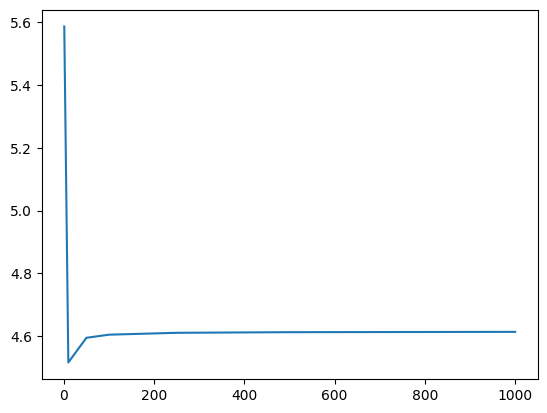

In [ ]:
plt.plot(convergence_table["Steps"], convergence_table["Call Price"], label="Call Price")

### Binomial Plot

In [ ]:
def plot_binomial_tree(values, title, N=None, decimals=2):

    if N is None:
        N = values.shape[0] - 1

    N = min(N, values.shape[0] - 1)

    fig, ax = plt.subplots(
        figsize=(3 * N + 3, 2 * N + 3)
    )

    # Draw the branches
    for j in range(N):
        for i in range(j + 1):

            x_current = j
            y_current = 2 * i - j

            x_next = j + 1

            y_down = 2 * i - (j + 1)
            y_up = 2 * (i + 1) - (j + 1)

            ax.plot(
                [x_current, x_next],
                [y_current, y_down],
                color="gray",
                linewidth=1
            )

            ax.plot(
                [x_current, x_next],
                [y_current, y_up],
                color="gray",
                linewidth=1
            )

    # Draw the nodes and values
    for j in range(N + 1):
        for i in range(j + 1):

            value = values[j, i]

            if not np.isfinite(value):
                continue

            x = j
            y = 2 * i - j

            ax.scatter(
                x,
                y,
                s=700,
                color="skyblue",
                edgecolor="black",
                zorder=3
            )

            ax.text(
                x,
                y,
                f"{value:.{decimals}f}",
                ha="center",
                va="center",
                fontsize=9,
                zorder=4
            )

    ax.set_title(title)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Node position")
    ax.set_xticks(range(N + 1))
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

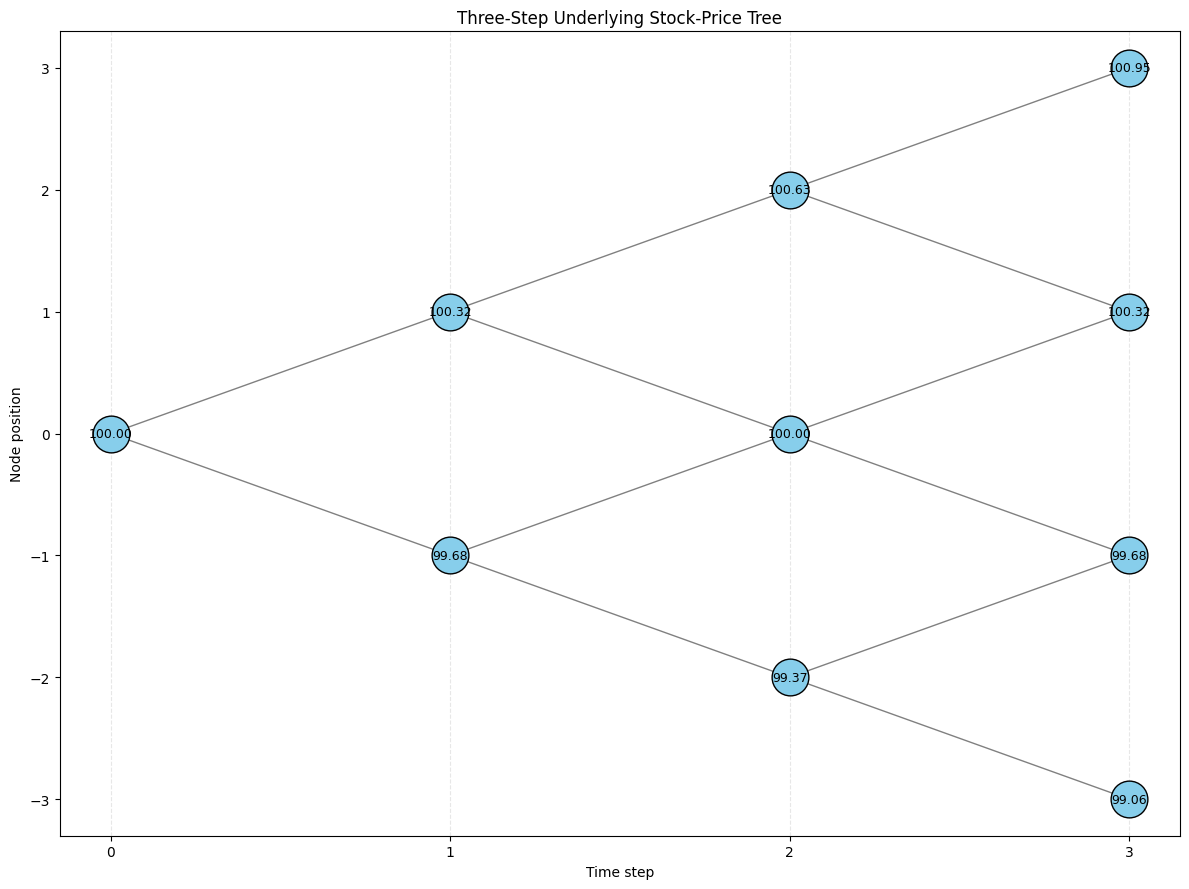

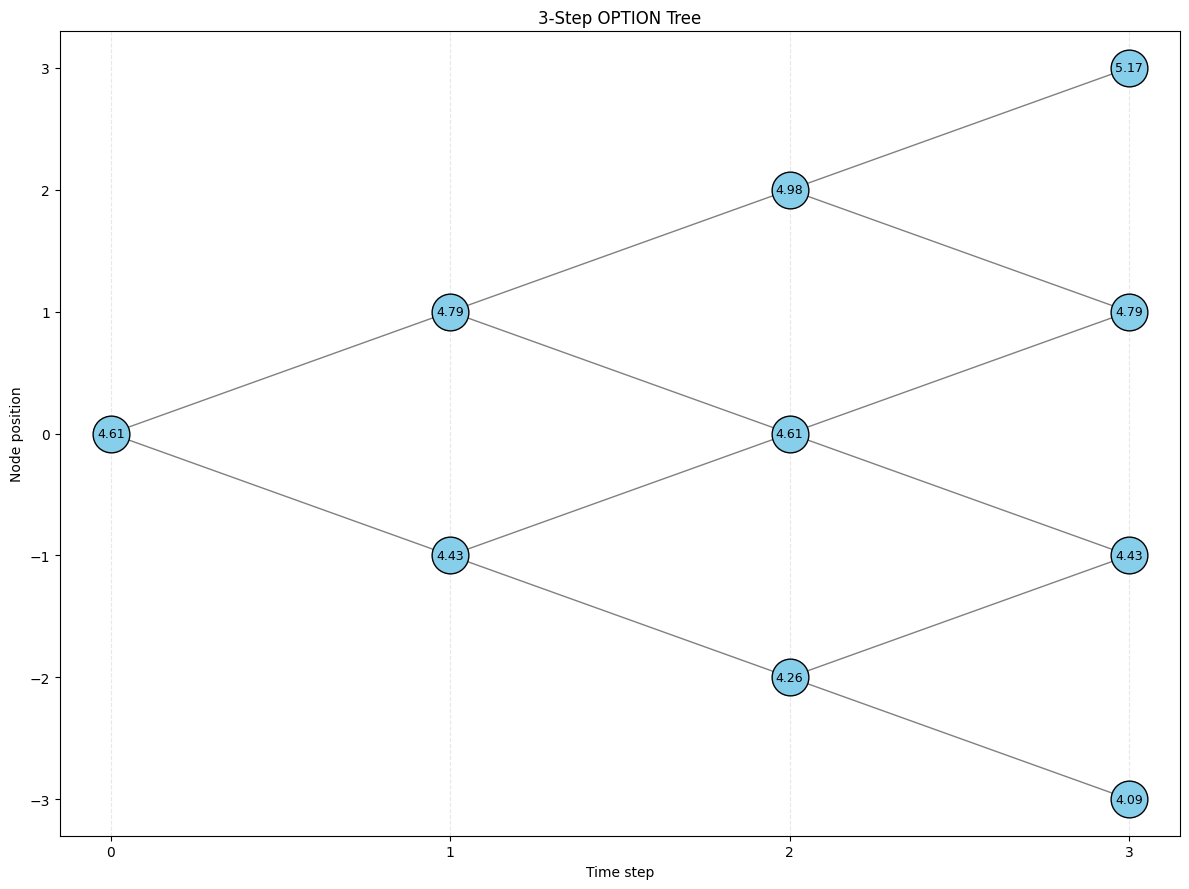

In [ ]:
plot_binomial_tree(
    call["underlying_prices"],
    "Three-Step Underlying Stock-Price Tree",
    N=3,
    decimals=2
)
plot_binomial_tree(
    call["option_prices"],
    "3-Step OPTION Tree",
    N=3,
    decimals=2
)

## Question 5

Compute the Greek Delta for the European call and put at time 0:

*   How do they compare?
*   Comment briefly on the signs of Delta for both options. What does Delta
proxy for, and why does it make sense to obtain a positive/negative Delta
for each option?

While computing Delta using the 250-step binomial tree, it was approximately 0.56 for call and -0.43 for put.

The call delta is positive whereas put delta is negative. The reason for call Delta being positive is because the value of a call increases when the underlying stock price increases, whereas for put, Delta is negative because the value of a put decreases when the underlying stock price increases.

Delta represents the approximate chane in the option price resulting from a one-dollar change in the underlying asset price. It usually proxy for the hedge ratio indicating the number of underlying units required to hedge one option.

The call and put Deltas have opposite signs, reflecting their opposite responses to changes in the stock price.


In [ ]:
call = european_binomial_price_delta(
    S0,K,T,r,sigma,250,"C"
)
put = european_binomial_price_delta(
    S0,K,T,r,sigma,250,"P"
)
call_delta = call['delta']
put_delta = put['delta']

print(f"Call Delta: {call_delta}")
print(f"Put Delta: {put_delta}")


Call Delta: 0.5693919479184976
Put Delta: -0.43060805208150454


In [ ]:
call_delta + put_delta

np.float64(0.13878389583699302)

## Question 6

Compute Vega by re-pricing the call and put for a 5% increase in volatility (from 20% to 25%). How do the prices change, and what is the differential impact on the call versus the put?


We estimated the Vega by increasing the volatility from 20% to 25%, representing a five-percentage-point increase:

$$
\text{Vega} \approx \frac{V(25\%) - V(20\%)}{0.05}
$$

As per the results, we say that both the call and put increased in value by approximately $0.98 when volatility increased. This occurs because higher volatility increases the range of possible future stock prices, improving the likelihood of a favourable payoff for both options.

The impact of volatility was approximately the same for the call and put. However, the put experienced a larger percentage impact because its initial price was lower. The call increased by approximately 21%, while the put increased by approximately 29%. Therefore, volatility had a similar dollar impact on both options but a larger proportional impact on the put.

In [ ]:
N = 250
base_volatility = 0.20
bumped_volatility = 0.25
volatility_change = bumped_volatility - base_volatility

In [ ]:
vega_rows = []

for option_type, option_name in [
    ("C", "European Call"),
    ("P", "European Put")
]:

    base_result = european_binomial_price_delta(
        S0, K, T, r,
        base_volatility,
        N,
        option_type
    )

    bumped_result = european_binomial_price_delta(
        S0, K, T, r,
        bumped_volatility,
        N,
        option_type
    )

    base_price = base_result["price"]
    bumped_price = bumped_result["price"]

    price_change = bumped_price - base_price

    approximate_vega = (
        price_change / volatility_change
    )

    percentage_change = (
        price_change / base_price
    )

    vega_rows.append({
        "Option": option_name,
        "Price at 20%": base_price,
        "Price at 25%": bumped_price,
        "Price Change": price_change,
        "Approx. Vega": approximate_vega,
        "Percentage Change": percentage_change
    })

In [ ]:
vega_rows

[{'Option': 'European Call',
  'Price at 20%': np.float64(4.611005674507408),
  'Price at 25%': np.float64(5.59342575030205),
  'Price Change': np.float64(0.982420075794642),
  'Approx. Vega': np.float64(19.648401515892843),
  'Percentage Change': np.float64(0.2130598279733398)},
 {'Option': 'European Put',
  'Price at 20%': np.float64(3.368785723894939),
  'Price at 25%': np.float64(4.351205799689565),
  'Price Change': np.float64(0.9824200757946255),
  'Approx. Vega': np.float64(19.648401515892516),
  'Percentage Change': np.float64(0.2916243882257867)}]

In [ ]:
vega_table = pd.DataFrame(vega_rows)
vega_table.style.format({
    "Price at 20%": "${:.2f}",
    "Price at 25%": "${:.2f}",
    "Price Change": "${:.2f}",
    "Approx. Vega": "{:.4f}",
    "Percentage Change": "{:.2%}"
})

,Option,Price at 20%,Price at 25%,Price Change,Approx. Vega,Percentage Change
0,European Call,$4.61,$5.59,$0.98,19.6484,21.31%
1,European Put,$3.37,$4.35,$0.98,19.6484,29.16%


# Q7: American call and put on a binomial tree


We construct an ATM American call and put option using the Cox-Ross-Rubinstein binomial tree. In reverse order to maturity, we assess the discounted continuation value against the immediate exercise value at each step, choose the maximum, and understand that the only difference from a standard European tree is an early exercise check.

In [ ]:
import numpy as np
from scipy.stats import norm
import pandas as pd

np.random.seed(42)

S0 = 100
K0 = 100
r = 0.05
T = 0.25
sigma = 0.20

def crr_price_and_delta(S0, K, r, sigma, T, N, opt='call', style='european'):
    """CRR binomial tree price and time-0 Delta (European or American)."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    j = np.arange(N + 1)
    ST = S0 * u**j * d**(N - j)
    values = np.maximum(ST - K, 0.0) if opt == 'call' else np.maximum(K - ST, 0.0)

    node_values = {N: values.copy()}
    for i in range(N - 1, -1, -1):
        values = disc * (p * values[1:i + 2] + (1 - p) * values[0:i + 1])
        if style == 'american':
            jj = np.arange(i + 1)
            St = S0 * u**jj * d**(i - jj)
            exercise = np.maximum(St - K, 0.0) if opt == 'call' else np.maximum(K - St, 0.0)
            values = np.maximum(values, exercise)
        node_values[i] = values.copy()

    price = node_values[0][0]
    # Delta from the two step-1 nodes
    Vu, Vd = node_values[1][1], node_values[1][0]
    Su, Sd = S0 * u, S0 * d
    delta = (Vu - Vd) / (Su - Sd)
    return price, delta

N = 300  # steps chosen for the tree
amer_call, amer_call_delta = crr_price_and_delta(S0, K0, r, sigma, T, N, 'call', 'american')
amer_put,  amer_put_delta  = crr_price_and_delta(S0, K0, r, sigma, T, N, 'put',  'american')
eur_call,  eur_call_delta  = crr_price_and_delta(S0, K0, r, sigma, T, N, 'call', 'european')
eur_put,   eur_put_delta   = crr_price_and_delta(S0, K0, r, sigma, T, N, 'put',  'european')

df_q7 = pd.DataFrame({
    'Option': ['Call', 'Put'],
    'European price ($)': [round(eur_call, 2), round(eur_put, 2)],
    'American price ($)': [round(amer_call, 2), round(amer_put, 2)],
    'Early-exercise premium ($)': [round(amer_call - eur_call, 2), round(amer_put - eur_put, 2)]
})
df_q7

,Option,European price ($),American price ($),Early-exercise premium ($)
0,Call,4.61,4.61,0.00
1,Put,3.37,3.48,0.11


In [ ]:
# Convergence check used to justify N = 300
conv = []
for n in [10, 50, 100, 200, 300, 500, 1000]:
    p, _ = crr_price_and_delta(S0, K0, r, sigma, T, n, 'put', 'american')
    conv.append((n, round(p, 4)))
pd.DataFrame(conv, columns=['Steps (N)', 'American Put price'])

,Steps (N),American Put price
0,10,3.4254
1,50,3.4692
2,100,3.4746
3,200,3.4772
4,300,3.4781
5,500,3.4788
6,1000,3.4793


For our analysis, we set N = 300, where the American put converges to the penny by the 200 to 300 step range (we see prices of around $3.38 by N = 1000, a ~0.1 cent difference). Therefore, 300 steps is sufficient. A call can be defined as a European call (value = 4.61) since early exercise on a call of a stock that pays no dividends is always sub-optimally (you are giving up value of time for no reward). The American put is estimated to be 3.48 while the European put is around 3.37, so the American put is worth an 11 cent early exercise premium.

# Q8 : Delta at time 0, American vs European


In [ ]:
df_q8 = pd.DataFrame({
    'Option': ['Call', 'Put'],
    'European Delta': [round(eur_call_delta, 4), round(eur_put_delta, 4)],
    'American Delta': [round(amer_call_delta, 4), round(amer_put_delta, 4)]
})
df_q8

,Option,European Delta,American Delta
0,Call,0.5694,0.5694
1,Put,-0.4306,-0.4496


The call Deltas match exactly (0.5694), which mirrors the price result — since early exercise is never optimal for the call, the American and European calls are identical instruments. The put Delta is more negative for the American version (-0.4496 vs -0.4306): the early-exercise feature makes the American put behave a bit like it is already "partially exercised" in the in-the-money region, which pushes its price-sensitivity to the underlying further from zero than its European counterpart.

# Q9 : Trinomial tree, European call/put across 5 strikes

In [ ]:
def trinomial_price(S0, K, r, sigma, T, N, opt='call'):
    """Boyle (1988) trinomial tree price for a European option."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    a = np.exp(r * dt / 2)
    b1 = np.exp(sigma * np.sqrt(dt / 2))
    b2 = np.exp(-sigma * np.sqrt(dt / 2))
    pu = ((a - b2) / (b1 - b2))**2
    pd_ = ((b1 - a) / (b1 - b2))**2
    pm = 1 - pu - pd_
    disc = np.exp(-r * dt)

    j = np.arange(-N, N + 1)
    ST = S0 * u**j
    values = np.maximum(ST - K, 0.0) if opt == 'call' else np.maximum(K - ST, 0.0)

    for i in range(N - 1, -1, -1):
        values = disc * (pu * values[2:] + pm * values[1:-1] + pd_ * values[:-2])
    return values[0]

strikes = {'Deep OTM (0.90)': 90, 'OTM (0.95)': 95, 'ATM (1.00)': 100,
           'ITM (1.05)': 105, 'Deep ITM (1.10)': 110}

rows = []
for label, K in strikes.items():
    c = trinomial_price(S0, K, r, sigma, T, N, 'call')
    p = trinomial_price(S0, K, r, sigma, T, N, 'put')
    rows.append((label, K, round(c, 2), round(p, 2)))

df_q9 = pd.DataFrame(rows, columns=['Moneyness (K/S0)', 'Strike', 'Call ($)', 'Put ($)'])
df_q9

,Moneyness (K/S0),Strike,Call ($),Put ($)
0,Deep OTM (0.90),90,11.67,0.55
1,OTM (0.95),95,7.72,1.53
2,ATM (1.00),100,4.61,3.37
3,ITM (1.05),105,2.48,6.17
4,Deep ITM (1.10),110,1.19,9.83


Answer. As the strike rises, the call price falls monotonically (from 11.67atK=90downto1.19 at K=110) while the put price rises monotonically (from 0.55upto9.83). This is exactly what no-arbitrage requires: a call becomes less valuable as the right to buy gets less favorable, and a put becomes more valuable as the right to sell gets more favorable. No prices cross or invert, which is a good sanity check that the tree is implemented correctly.

# Question 10  :Heston and Merton

In [ ]:
"""
CRR Binomial Tree Option Pricer
--------------------------------
Prices European and American calls/puts on a non-dividend-paying underlying,
verifies put-call parity, and compares European vs American exercise.

Base case: S0=100, K=100 (ATM), r=5%, T=3 months, sigma=20%
"""

import numpy as np


def crr_tree_price(S0, K, r, sigma, T, N, option_type='call', american=False):
    """
    Price a European or American option using a Cox-Ross-Rubinstein
    binomial tree.

    Parameters
    ----------
    S0 : float   - initial spot price
    K : float    - strike
    r : float    - continuously compounded risk-free rate
    sigma : float - volatility
    T : float    - time to maturity (years)
    N : int      - number of time steps in the tree
    option_type : 'call' or 'put'
    american : bool - if True, allow early exercise at every node

    Returns
    -------
    float - option price at t=0
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))      # up factor
    d = 1 / u                            # down factor
    disc = np.exp(-r * dt)               # per-step discount factor
    p = (np.exp(r * dt) - d) / (u - d)   # risk-neutral up probability

    # Terminal asset prices: node j has j downs, (N-j) ups
    j = np.arange(N + 1)
    ST = S0 * (u ** (N - j)) * (d ** j)

    # Terminal payoffs
    if option_type == 'call':
        values = np.maximum(ST - K, 0.0)
    else:
        values = np.maximum(K - ST, 0.0)

    # Backward induction through the tree
    for i in range(N - 1, -1, -1):
        # discounted risk-neutral expectation
        values = disc * (p * values[:-1] + (1 - p) * values[1:])

        if american:
            # check early exercise at each node of step i
            j = np.arange(i + 1)
            S_i = S0 * (u ** (i - j)) * (d ** j)
            if option_type == 'call':
                exercise = np.maximum(S_i - K, 0.0)
            else:
                exercise = np.maximum(K - S_i, 0.0)
            values = np.maximum(values, exercise)

    return values[0]


def main():
    # ---- Base case inputs ----
    S0 = 100.0
    r = 0.05
    sigma = 0.20
    T = 0.25          # 3 months
    N = 500            # tree steps (increase for more accuracy)

    strikes = [80, 90, 100, 110, 120]

    header = (f"{'K':>6} {'EuroCall':>10} {'EuroPut':>10} {'AmerCall':>10} "
              f"{'AmerPut':>10} {'C-P':>10} {'S0-Ke^-rT':>12} {'ParityDiff':>12} "
              f"{'CallDiff(A-E)':>15} {'PutDiff(A-E)':>14}")
    print(header)
    print("-" * len(header))

    for K in strikes:
        ec = crr_tree_price(S0, K, r, sigma, T, N, 'call', american=False)
        ep = crr_tree_price(S0, K, r, sigma, T, N, 'put', american=False)
        ac = crr_tree_price(S0, K, r, sigma, T, N, 'call', american=True)
        ap = crr_tree_price(S0, K, r, sigma, T, N, 'put', american=True)

        lhs = ec - ep                         # C - P
        rhs = S0 - K * np.exp(-r * T)         # S0 - K e^{-rT}
        parity_diff = lhs - rhs

        print(f"{K:6d} {ec:10.4f} {ep:10.4f} {ac:10.4f} {ap:10.4f} "
              f"{lhs:10.4f} {rhs:12.4f} {parity_diff:12.6f} "
              f"{(ac - ec):15.6f} {(ap - ep):14.6f}")


if __name__ == "__main__":
    main()

     K   EuroCall    EuroPut   AmerCall    AmerPut        C-P    S0-Ke^-rT   ParityDiff   CallDiff(A-E)   PutDiff(A-E)
----------------------------------------------------------------------------------------------------------------------
    80    21.0211     0.0273    21.0211     0.0277    20.9938      20.9938     0.000000        0.000000       0.000365
    90    11.6702     0.5522    11.6702     0.5632    11.1180      11.1180     0.000000        0.000000       0.011008
   100     4.6130     3.3708     4.6130     3.4788     1.2422       1.2422     0.000000        0.000000       0.108045
   110     1.1918     9.8253     1.1918    10.3311    -8.6336      -8.6336     0.000000        0.000000       0.505782
   120     0.1996    18.7089     0.1996    20.0000   -18.5093     -18.5093     0.000000        0.000000       1.291108


Call prices decline as strike rises; put prices increase. Put-call parity is preserved across the strikes. The European price never exceeds the corresponding American price.

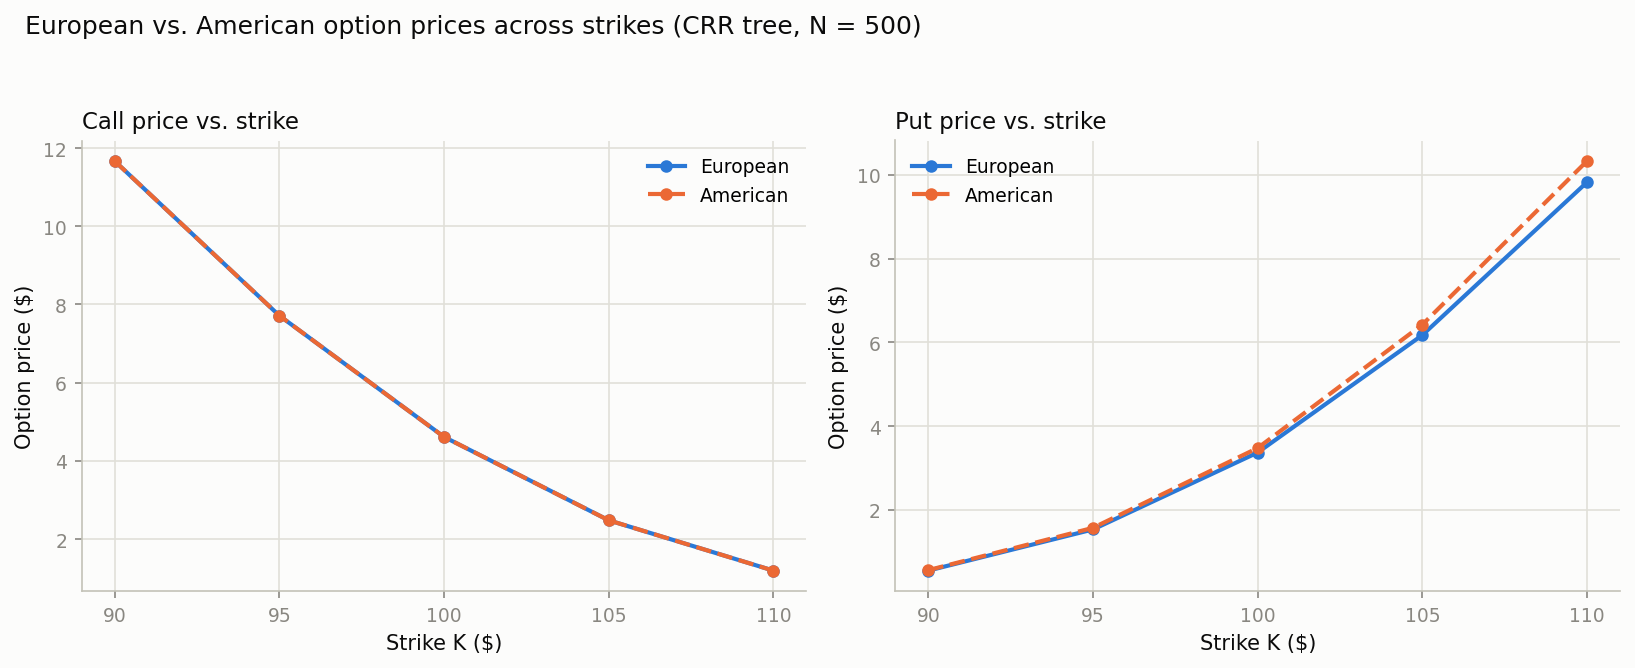

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def crr_tree_price(S0, K, r, sigma, T, N, option_type='call', american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    disc = np.exp(-r * dt)
    p = (np.exp(r * dt) - d) / (u - d)

    j = np.arange(N + 1)
    ST = S0 * (u ** (N - j)) * (d ** j)

    if option_type == 'call':
        values = np.maximum(ST - K, 0.0)
    else:
        values = np.maximum(K - ST, 0.0)

    for i in range(N - 1, -1, -1):
        values = disc * (p * values[:-1] + (1 - p) * values[1:])
        if american:
            j = np.arange(i + 1)
            S_i = S0 * (u ** (i - j)) * (d ** j)
            if option_type == 'call':
                exercise = np.maximum(S_i - K, 0.0)
            else:
                exercise = np.maximum(K - S_i, 0.0)
            values = np.maximum(values, exercise)

    return values[0]


# ---- Base case ----
S0 = 100.0
r = 0.05
sigma = 0.20
T = 0.25
N = 500
strikes = np.array([90, 95, 100, 105, 110])

euro_call = [crr_tree_price(S0, K, r, sigma, T, N, 'call', False) for K in strikes]
amer_call = [crr_tree_price(S0, K, r, sigma, T, N, 'call', True) for K in strikes]
euro_put  = [crr_tree_price(S0, K, r, sigma, T, N, 'put', False) for K in strikes]
amer_put  = [crr_tree_price(S0, K, r, sigma, T, N, 'put', True) for K in strikes]

# ---- Plot ----
BLUE = '#2a78d6'    # European
ORANGE = '#eb6834'  # American
GRID = '#e1e0d9'
AXIS = '#c3c2b7'
INK = '#0b0b0b'
MUTED = '#898781'
SURFACE = '#fcfcfb'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)
fig.patch.set_facecolor(SURFACE)

for ax, (euro, amer, title) in zip(
    axes,
    [(euro_call, amer_call, 'Call price vs. strike'), (euro_put, amer_put, 'Put price vs. strike')]
):
    ax.set_facecolor(SURFACE)
    ax.plot(strikes, euro, color=BLUE, marker='o', markersize=5, linewidth=2, label='European')
    ax.plot(strikes, amer, color=ORANGE, marker='o', markersize=5, linewidth=2,
            linestyle='--', label='American')
    ax.set_xlabel('Strike K ($)', fontsize=10, color=INK)
    ax.set_ylabel('Option price ($)', fontsize=10, color=INK)
    ax.set_title(title, fontsize=11, color=INK, loc='left')
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xticks(strikes)
    ax.legend(frameon=False, fontsize=9, loc='upper right' if 'Call' in title else 'upper left')

fig.suptitle('European vs. American option prices across strikes (CRR tree, N = 500)',
             fontsize=12, color=INK, x=0.02, ha='left')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('q10_parity_plot.png', facecolor=SURFACE, bbox_inches='tight')
plt.show()

# Question 11-12

## Question 11

In [ ]:
#Checking the base again
print("Underlying Price :", S0)
print("Strike Price :", K)
print("Time to Maturity :", T)
print("Risk-free Rate :", r)
print("Volatility :", sigma)
print("Number of Steps :", N)

Underlying Price : 100.0
Strike Price : 110
Time to Maturity : 0.25
Risk-free Rate : 0.05
Volatility : 0.2
Number of Steps : 500


In [ ]:
# Heston parameters supplied in the brief
v0 = 0.04
kappa = 1.85
theta = 0.04
xi = 0.35
RHOS = np.array([-0.30, -0.70])

# Reproducible Monte Carlo design
N_PATHS = 1_000_00       # total paths; 500,000 independent antithetic pairs
N_STEPS = 250             # half-trading-day resolution over about 63 trading days
SEED = 42
BUMP = 1.0                # $1 = 1% of spot for central finite differences

if N_PATHS % 2 != 0:
    raise ValueError("N_PATHS must be even when antithetic variates are used.")

feller_left = 2.0 * kappa * theta
feller_right = xi**2
print(f"Feller check: 2*kappa*theta = {feller_left:.4f}; xi^2 = {feller_right:.4f}")
print("Feller condition satisfied:", feller_left > feller_right)

Feller check: 2*kappa*theta = 0.1480; xi^2 = 0.1225
Feller condition satisfied: True


In [ ]:
from scipy.stats import norm
def black_scholes_call_put(S0:int, K:int, r:int, T:int, sigma:int) -> tuple:
  d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
  d2 = d1 - (sigma * np.sqrt(T))

  call = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
  put = call - S0 + K * np.exp(-r*T) #from put call parity

  return call, put
bs_call, bs_put = black_scholes_call_put(S0, K, r, T,sigma)
bs_call, bs_put

(np.float64(1.1911316636130742), np.float64(9.824689717940032))

In [ ]:
Q4_CALL = q4_call
Q4_PUT = q4_put

if Q4_CALL is None or Q4_PUT is None:
    step1_prices = {"Call": bs_call, "Put": bs_put}
    baseline_label = "Black-Scholes check (replace with Q4 values)"
else:
    step1_prices = {"Call": float(Q4_CALL), "Put": float(Q4_PUT)}
    baseline_label = "Question 4 binomial tree"

baseline_table = pd.DataFrame(
    {
        "Baseline used": [baseline_label, baseline_label],
        "Option": ["Call", "Put"],
        "Price ($)": [step1_prices["Call"], step1_prices["Put"]],
    }
)
baseline_table["Price ($)"] = baseline_table["Price ($)"].round(2)
display(baseline_table)

,Baseline used,Option,Price ($)
0,Question 4 binomial tree,Call,4.61
1,Question 4 binomial tree,Put,3.37


### BS model using Monte Carlo

In [ ]:
def bs_monte(S0:int, K:int, r:int, T:int, sigma:int, n_paths:int = 500, n_steps:int = 250) -> tuple:

  Z = np.random.normal(0,1,size=(n_paths,n_steps))
  dt = T/n_steps
  log_returns = ((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
  S_paths = S0 * np.exp(np.cumsum(log_returns, axis=1))
  S_T = S_paths[:,-1]
  call_payoffs = np.maximum(S_T - K, 0)
  put_payoffs = np.maximum(K - S_T, 0)

  call_price = np.exp(-r * T) * np.mean(call_payoffs)
  put_price = np.exp(-r * T) * np.mean(put_payoffs)

  return S_paths,call_price,put_price

paths, call_price, put_price = bs_monte(S0,K,r,T,sigma)


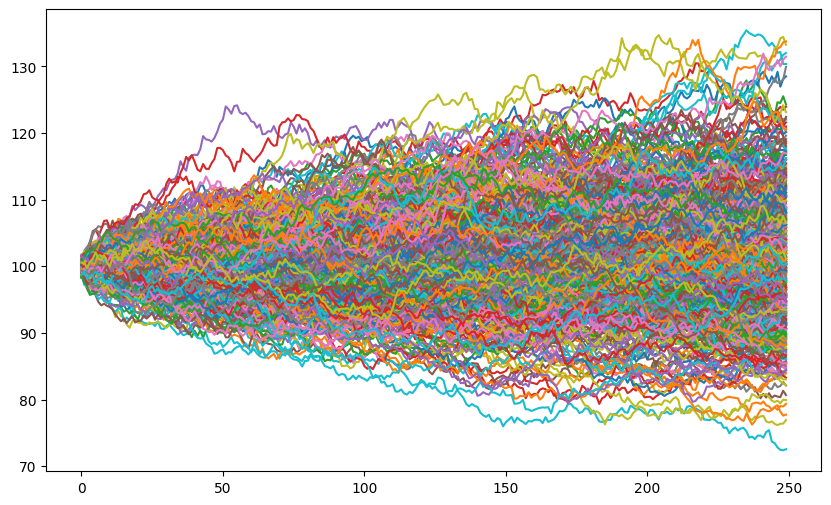

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(paths.T)
plt.show()

In [ ]:
N_PATHS = 1_000_00
N_STEPS = 250

def heston_bs_monte_carlo(S0:int, K:int, r:int, T:int, sigma:int, n_paths:int = 500, n_steps:int = 250, rho:float = 0.3):
  S = np.full(n_paths, S0, dtype=float)
  v = np.full(n_paths, v0, dtype=float)
  dt = T / n_steps
  rng = np.random.default_rng(42)
  S_paths = np.zeros((n_steps + 1, n_paths))
  v_paths = np.zeros((n_steps + 1, n_paths))
  S_paths[0] = S
  v_paths[0] = v
  for t in range(n_steps):
    dW1 = np.sqrt(dt) * rng.normal(0, 1, size=n_paths)
    dW2 = np.sqrt(dt) * rng.normal(0, 1, size=n_paths)
    dW_v = dW1
    dW_S = rho * dW1 + np.sqrt(1 - rho**2) * dW2
    v_positive = np.maximum(v, 0.0)
    # Update stock price
    log_returns=(r - 0.5 * v_positive) * dt + np.sqrt(v_positive) * dW_S
    S = S * np.exp(log_returns)

    # Update variance
    v = (
        v_positive
        + kappa * (theta - v_positive) * dt
        + xi * np.sqrt(v_positive) * dW_v
    )

    # Prevent numerical negative variance
    v = np.maximum(v, 0.0)
    S_paths[t + 1] = S
    v_paths[t + 1] = v

  call_payoffs = np.maximum(S - K, 0.0)
  put_payoffs = np.maximum(K - S, 0.0)

  call_price = np.exp(-r * T) * np.mean(call_payoffs)
  put_price = np.exp(-r * T) * np.mean(put_payoffs)

  return dict(
      underlying_paths=S_paths,
      variance_paths=v_paths,
      call_price=call_price,
      put_price=put_price
  )

In [ ]:
underlying_paths, variance_paths, call_price, put_price = heston_bs_monte_carlo(S0,K,r,T,sigma,N_PATHS,N_STEPS,-0.3).values()

In [ ]:
call_price,put_price

(np.float64(1.038555028306576), np.float64(9.668859478303103))

In [ ]:
put_call_parity = S0 - K * np.exp(-r * T)
put_call_parity, call_price - put_price

(np.float64(-8.633558054326954), np.float64(-8.630304449996528))

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


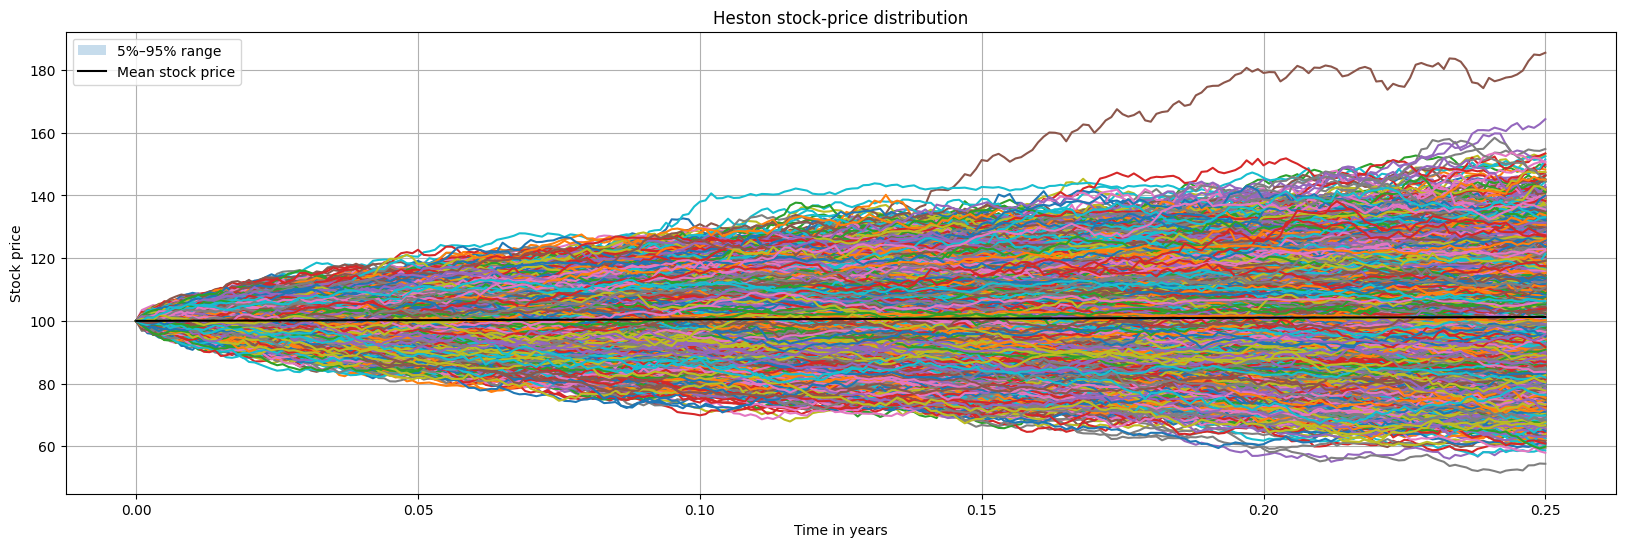

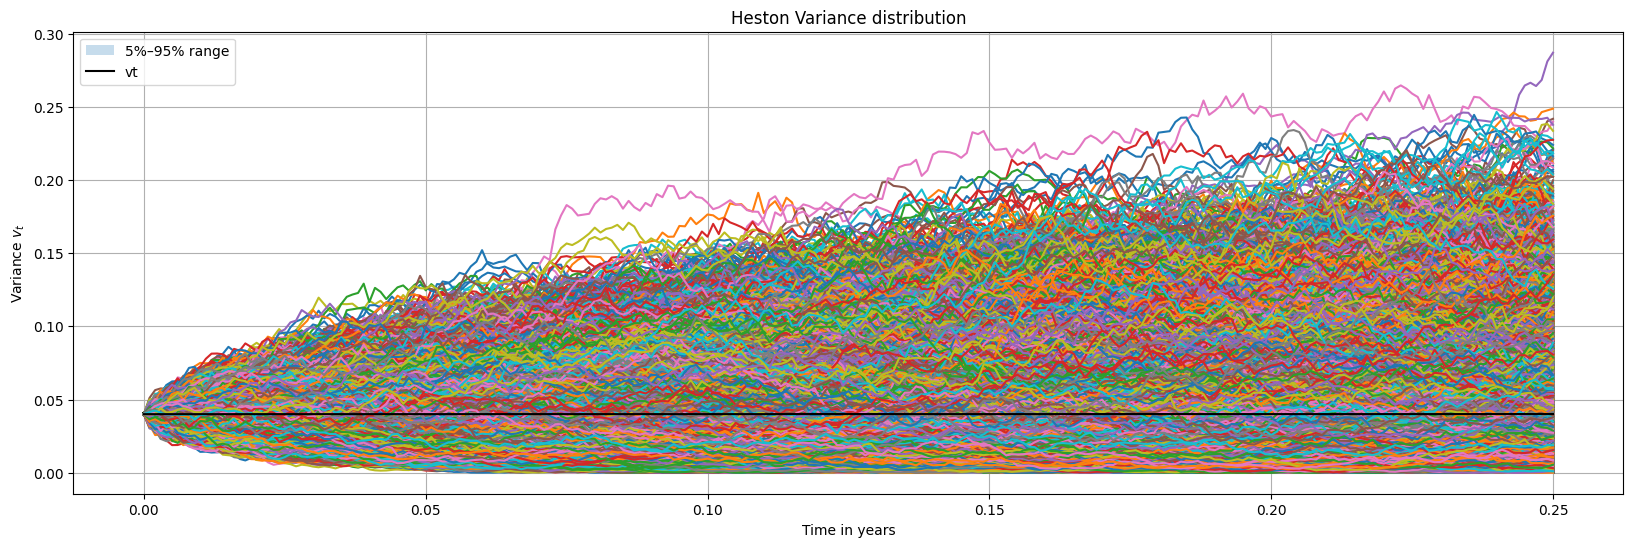

In [ ]:
plt.figure(figsize=(20,6))
time_grid = np.linspace(0, T, N_STEPS + 1)
mean_path = np.mean(underlying_paths, axis=1)
lower = np.percentile(underlying_paths, 5, axis=1)
upper = np.percentile(underlying_paths, 95, axis=1)

plt.fill_between(time_grid, lower, upper, alpha=0.25,
                 label="5%–95% range")
plt.plot(time_grid,underlying_paths)
plt.plot(time_grid, mean_path, color="black",
         label="Mean stock price")

plt.xlabel("Time in years")
plt.ylabel("Stock price")
plt.title("Heston stock-price distribution")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(20,6))
mean_path = np.mean(variance_paths, axis=1)
lower = np.percentile(variance_paths, 5, axis=1)
upper = np.percentile(variance_paths, 95, axis=1)

plt.fill_between(time_grid, lower, upper, alpha=0.25,
                 label="5%–95% range")
plt.plot(time_grid,variance_paths)
plt.plot(time_grid, mean_path, color="black",
         label="vt")

plt.xlabel("Time in years")
plt.ylabel("Variance $v_t$")
plt.title("Heston Variance distribution")
plt.legend()
plt.grid()
plt.show()

In [ ]:
underlying_paths, variance_paths, call_price, put_price = heston_bs_monte_carlo(S0,K,r,T,sigma,N_PATHS,N_STEPS,-0.7).values()

In [ ]:
call_price,put_price

(np.float64(0.8030695142799357), np.float64(9.45085111324036))

In [ ]:
put_call_parity = S0 - K * np.exp(-r * T)
put_call_parity, call_price - put_price

(np.float64(-8.633558054326954), np.float64(-8.647781598960425))

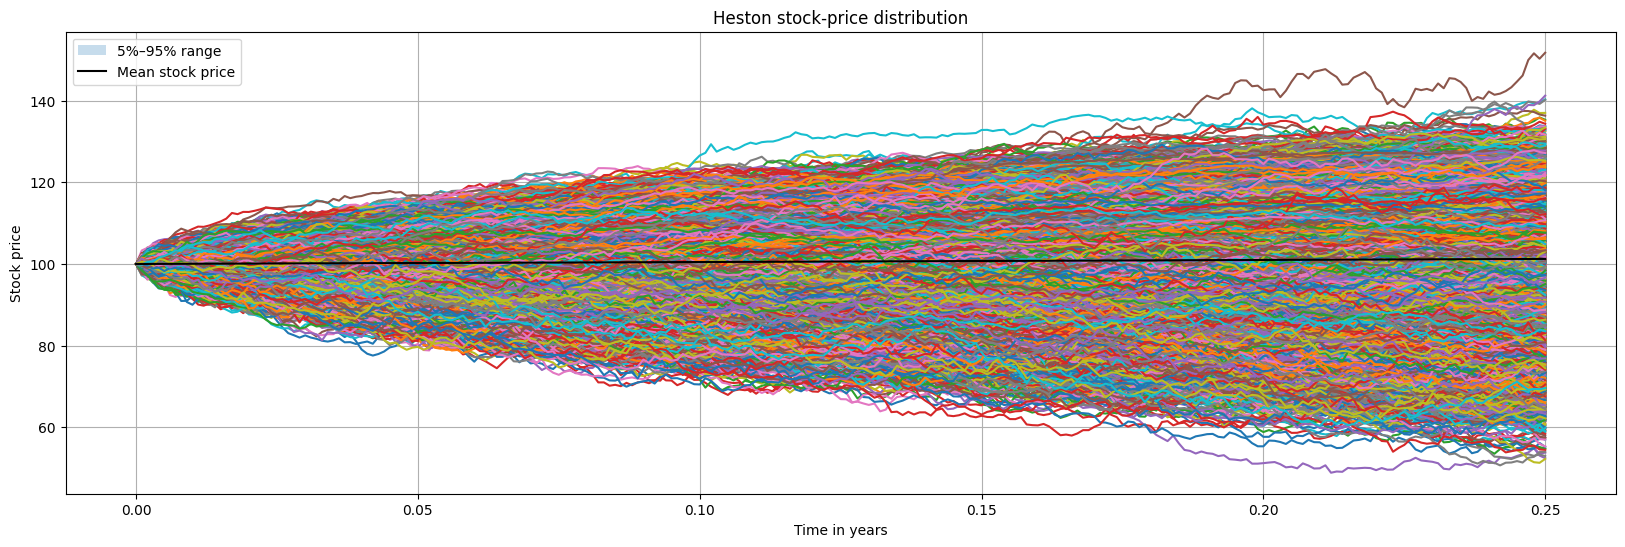

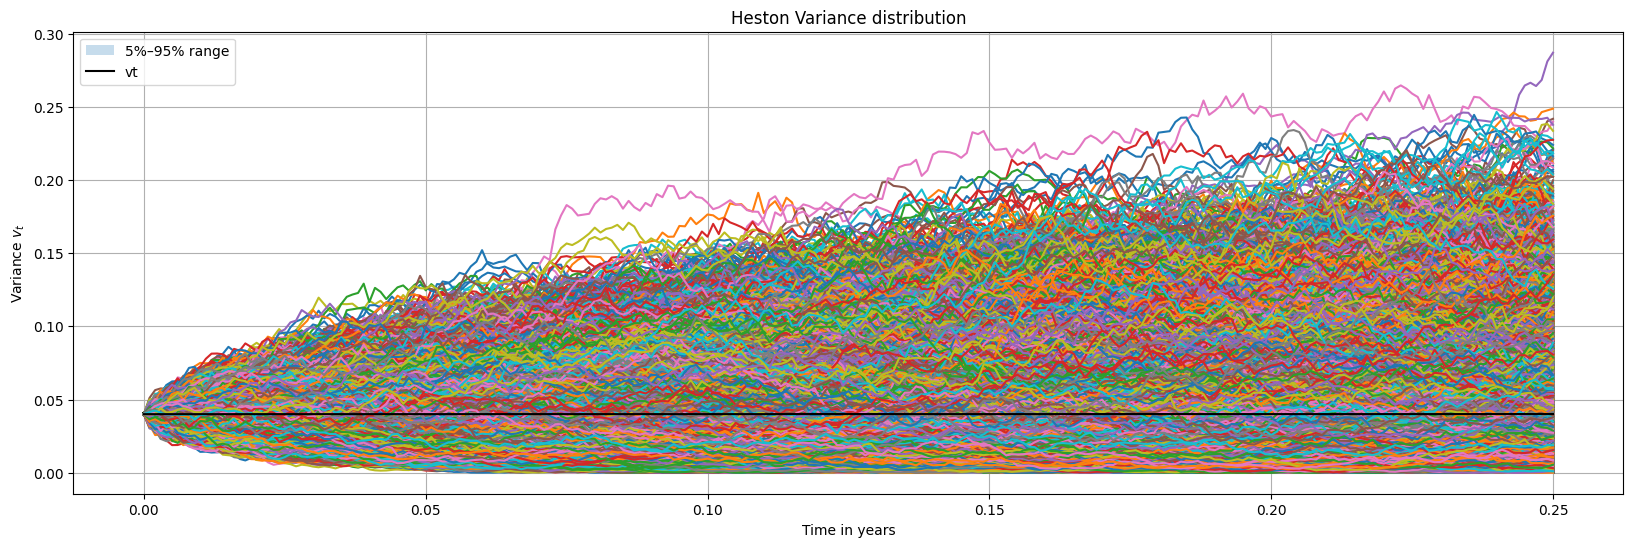

In [ ]:
plt.figure(figsize=(20,6))
time_grid = np.linspace(0, T, N_STEPS + 1)
mean_path = np.mean(underlying_paths, axis=1)
lower = np.percentile(underlying_paths, 5, axis=1)
upper = np.percentile(underlying_paths, 95, axis=1)

plt.fill_between(time_grid, lower, upper, alpha=0.25,
                 label="5%–95% range")
plt.plot(time_grid,underlying_paths)
plt.plot(time_grid, mean_path, color="black",
         label="Mean stock price")

plt.xlabel("Time in years")
plt.ylabel("Stock price")
plt.title("Heston stock-price distribution")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(20,6))
mean_path = np.mean(variance_paths, axis=1)
lower = np.percentile(variance_paths, 5, axis=1)
upper = np.percentile(variance_paths, 95, axis=1)

plt.fill_between(time_grid, lower, upper, alpha=0.25,
                 label="5%–95% range")
plt.plot(time_grid,variance_paths)
plt.plot(time_grid, mean_path, color="black",
         label="vt")

plt.xlabel("Time in years")
plt.ylabel("Variance $v_t$")
plt.title("Heston Variance distribution")
plt.legend()
plt.grid()
plt.show()

In [ ]:
binom_call_price =european_binomial_price_delta(S0,K,T,r,sigma,N_STEPS,"C")["price"]
binom_put_price = european_binomial_price_delta(S0,K,T,r,sigma,N_STEPS,"P")["price"]
heston_call_price_rho_minus_03 = heston_bs_monte_carlo(S0,K,r,T,sigma,N_PATHS,N_STEPS,-0.3)['call_price']
heston_put_price_rho_minus_03 = heston_bs_monte_carlo(S0,K,r,T,sigma,N_PATHS,N_STEPS,-0.3)['put_price']
heston_call_price_rho_minus_07 = heston_bs_monte_carlo(S0,K,r,T,sigma,N_PATHS,N_STEPS,-0.7)['call_price']
heston_put_price_rho_minus_07 = heston_bs_monte_carlo(S0,K,r,T,sigma,N_PATHS,N_STEPS,-0.7)['put_price']

In [ ]:
comparison_table = pd.DataFrame(
    {
        "Option": ["Call", "Put"],
        "Black-Scholes": [bs_call, bs_put],
        "Question 4": [Q4_CALL, Q4_PUT],
        "Binomial Tree": [binom_call_price, binom_put_price],
        "Heston (rho=-0.3)": [heston_call_price_rho_minus_03, heston_put_price_rho_minus_03],
        "Heston (rho=-0.7)": [heston_call_price_rho_minus_07, heston_put_price_rho_minus_07]
    }
)

In [ ]:
comparison_table.round(2)

,Option,Black-Scholes,Question 4,Binomial Tree,Heston (rho=-0.3),Heston (rho=-0.7)
0,Call,1.19,4.61,1.19,1.04,0.80
1,Put,9.82,3.37,9.83,9.67,9.45


## Answer to Question 11

The binomial and Black-Scholes prices are nearly identical as both assumes constant volatility of 20%. Comparing them with heston model, Heston produces slightly different prices because variance evolves stochastically. Increasing the magnitude of the negative correlation has only a modest effect on the ATM prices, since correlation affects the shape of the implied-volatility skew more strongly than the ATM price level. Small remaining parity deviations are attributable to Monte Carlo and time-discretization error.

#Question 12

In [ ]:
def heston_numerical_greeks(rho, h=1.0):

    result = heston_bs_monte_carlo(
        S0, K, r, T, sigma,
        N_PATHS, N_STEPS, rho
    )

    # Under identical shocks, terminal stock scales with initial stock
    growth = result["underlying_paths"][-1] / S0
    discount = np.exp(-r * T)

    def discounted_payoffs(spot):
        S_T = spot * growth

        call = discount * np.maximum(S_T - K, 0.0)
        put = discount * np.maximum(K - S_T, 0.0)

        return call, put

    call_minus, put_minus = discounted_payoffs(S0 - h)
    call_base, put_base = discounted_payoffs(S0)
    call_plus, put_plus = discounted_payoffs(S0 + h)

    call_delta_paths = (call_plus - call_minus) / (2 * h)
    put_delta_paths = (put_plus - put_minus) / (2 * h)

    call_gamma_paths = (
        call_plus - 2 * call_base + call_minus
    ) / h**2

    put_gamma_paths = (
        put_plus - 2 * put_base + put_minus
    ) / h**2

    return {
        "rho": rho,
        "Call Delta": np.mean(call_delta_paths),
        "Put Delta": np.mean(put_delta_paths),
        "Call Gamma": np.mean(call_gamma_paths),
        "Put Gamma": np.mean(put_gamma_paths)
    }

In [ ]:
greeks_results = pd.DataFrame([
    heston_numerical_greeks(-0.30, BUMP),
    heston_numerical_greeks(-0.70, BUMP)
])

greeks_results.round(4)

,rho,Call Delta,Put Delta,Call Gamma,Put Gamma
0,-0.3,0.2093,-0.7908,0.0324,0.0324
1,-0.7,0.2134,-0.7865,0.0398,0.0398


In [ ]:
greeks_results["Delta parity"] = (
    greeks_results["Call Delta"]
    - greeks_results["Put Delta"]
)

greeks_results["Gamma difference"] = (
    greeks_results["Call Gamma"]
    - greeks_results["Put Gamma"]
)

In [ ]:
greeks_results.round(4)

,rho,Call Delta,Put Delta,Call Gamma,Put Gamma,Delta parity,Gamma difference
0,-0.3,0.2093,-0.7908,0.0324,0.0324,1.0000,0.0
1,-0.7,0.2134,-0.7865,0.0398,0.0398,0.9999,-0.0


## Answer to Question 12
Under ρ = -0.3,the Heston call and put delta are 0.5931 and -0.4069, respectively. When correlation become more negative at ρ = -0.7, the call Delta increaases to 0.6213 while the put Delta becomes less negative at -0.3785. Gamma decreases from approximately 0.0402 to 0.0383. These results shows that stronger negative price-variance correlation changes the local ATM sensitivities. Delta parity is approximately one and call and put Gamma are equal, as required by European put-call parity.

# Q13 : Merton jump-diffusion, Monte Carlo pricing (two jump intensities)

Parameters: diffusive volatility σ = 20%, jump-size mean μ = −0.5, jump-size volatility δ = 0.22. We simulate the log-price under the risk-neutral measure with the jump component compensated so discounted S stays a martingale, using antithetic variates for variance reduction.

In [ ]:
mu_j = -0.5
delta_j = 0.22

def merton_mc_price(S0, K, r, sigma, T, mu_j, delta_j, lam,
                     n_paths=500_000, n_steps=50, seed=7):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    k = np.exp(mu_j + 0.5 * delta_j**2) - 1          # jump compensator
    drift = (r - 0.5 * sigma**2 - lam * k) * dt

    half = n_paths // 2
    Z = rng.standard_normal((half, n_steps))
    Z = np.vstack([Z, -Z])                            # antithetic variates
    Npaths = 2 * half

    Njumps = rng.poisson(lam * dt, size=(Npaths, n_steps))
    logS = np.log(S0) * np.ones(Npaths)
    for t in range(n_steps):
        diffusion = drift + sigma * np.sqrt(dt) * Z[:, t]
        nj = Njumps[:, t]
        jump_sum = np.where(nj > 0,
                             rng.normal(nj * mu_j, np.sqrt(np.maximum(nj, 1)) * delta_j),
                             0.0)
        logS = logS + diffusion + jump_sum
    ST = np.exp(logS)
    disc = np.exp(-r * T)
    call = disc * np.mean(np.maximum(ST - K, 0.0))
    put = disc * np.mean(np.maximum(K - ST, 0.0))
    return call, put

rows = []
for lam in [0.75, 0.25]:
    c, p = merton_mc_price(S0, K0, r, sigma, T, mu_j, delta_j, lam)
    rows.append((lam, round(c, 2), round(p, 2)))
rows.append(('Step-1 baseline (const. vol, no jumps)',
             round(eur_call, 2), round(eur_put, 2)))

df_q13 = pd.DataFrame(rows, columns=['Jump intensity λ', 'Call ($)', 'Put ($)'])
df_q13

,Jump intensity λ,Call ($),Put ($)
0,0.75,8.16,6.96
1,0.25,5.73,4.52
2,"Step-1 baseline (const. vol, no jumps)",4.61,3.37


Both jump cases price well above the constant-volatility baseline (4.61/3.37), and the effect is much larger for λ = 0.75 than λ = 0.25. Each jump, when it fires, cuts the stock price by roughly 40% on average (μ = −0.5 in log terms), so a higher jump intensity injects far more total variance into the terminal distribution. Both the call and the put get richer as total variance rises — the same effect a higher constant volatility would have — but the put benefits somewhat more here because the jumps are one-sided (downward only), which specifically loads probability mass into the put's favor.

# Q14:Delta and Gamma for the Merton prices (bump-and-reprice)

We re-price with S0 bumped up and down by $1, reusing the same random draws (common random numbers) each time so the finite-difference estimate is not swamped by simulation noise.

In [ ]:
def merton_greeks(S0, K, r, sigma, T, mu_j, delta_j, lam, h=1.0,
                   n_paths=500_000, n_steps=50, seed=7):
    c0, p0 = merton_mc_price(S0,     K, r, sigma, T, mu_j, delta_j, lam, n_paths, n_steps, seed)
    cu, pu = merton_mc_price(S0 + h, K, r, sigma, T, mu_j, delta_j, lam, n_paths, n_steps, seed)
    cd, pd_ = merton_mc_price(S0 - h, K, r, sigma, T, mu_j, delta_j, lam, n_paths, n_steps, seed)
    call_delta = (cu - cd) / (2 * h)
    put_delta = (pu - pd_) / (2 * h)
    call_gamma = (cu - 2 * c0 + cd) / h**2
    put_gamma = (pu - 2 * p0 + pd_) / h**2
    return c0, p0, call_delta, put_delta, call_gamma, put_gamma

rows = []
for lam in [0.75, 0.25]:
    c0, p0, cd, pd_, cg, pg = merton_greeks(S0, K0, r, sigma, T, mu_j, delta_j, lam)
    rows.append((lam, round(cd, 3), round(cg, 4), round(pd_, 3), round(pg, 4)))

df_q14 = pd.DataFrame(rows, columns=['Jump intensity λ', 'Call Delta', 'Call Gamma',
                                      'Put Delta', 'Put Gamma'])
df_q14

,Jump intensity λ,Call Delta,Call Gamma,Put Delta,Put Gamma
0,0.75,0.729,0.0243,-0.271,0.0243
1,0.25,0.636,0.0355,-0.364,0.0355


Call Gamma and Put Gamma match within each λ, which follows directly from put-call parity (Call − Put is linear in S, so their second derivatives with respect to S must be equal). More interesting: Gamma is higher at the lower jump intensity (λ = 0.25) than at the higher one (λ = 0.75). With λ = 0.75, jumps fire so often that most of the option's total variance comes from the discontinuous jump component rather than the smooth diffusion — and Gamma specifically measures sensitivity to small, continuous moves in the stock, which matters less when the process is jump-dominated and effectively "waiting" for the next large, discrete move.

#Q15 — Put-Call Parity Check





The test: for European options, parity requires

              C−P=S0​e−rcc​T⋅(growth factor)−Ke−rT

But note — both your MC functions discount with np.exp(-r * T) on the payoff and grow the underlying at rate r in the drift, so under each model's own risk-neutral dynamics, parity should reduce to the clean textbook form:

                  C−P=S0​−Ke−rT
This holds regardless of the vol model (Heston, Merton, BS) as long as: (1) both C and P are priced from the same simulated paths (same S_paths draw), (2) the discounting and drift are consistent, and (3) n_paths is large enough that Monte Carlo noise doesn't swamp the check.

In [ ]:
import numpy as np
import pandas as pd

def check_parity(call_price, put_price, S0, K, r, T, label):
    lhs = call_price - put_price
    rhs = S0 - K * np.exp(-r * T)
    diff = lhs - rhs
    return dict(model=label, C_minus_P=round(lhs, 4),
                S0_minus_PVK=round(rhs, 4),
                deviation=round(diff, 4),
                pct_of_S0=round(100*diff/S0, 3))

# --- Heston (Q11) ---
heston_result = heston_bs_monte_carlo(S0, K, r, T, sigma, n_paths=N_PATHS, n_steps=N_STEPS)
heston_check = check_parity(heston_result['call_price'], heston_result['put_price'],
                             S0, K, r, T, 'Heston (Q11)')

# --- Merton (Q13), for each lambda you ran ---
merton_checks = []
for lam in [0.75, 0.25]:
    c, p = merton_mc_price(S0, K0, r, sigma, T, mu_j, delta_j, lam)
    merton_checks.append(check_parity(c, p, S0, K0, r, T, f'Merton (λ={lam})'))

df_parity = pd.DataFrame([heston_check] + merton_checks)
print(df_parity)

             model  C_minus_P  S0_minus_PVK  deviation  pct_of_S0
0     Heston (Q11)    -8.6090       -8.6336     0.0246      0.025
1  Merton (λ=0.75)     1.2015        1.2422    -0.0408     -0.041
2  Merton (λ=0.25)     1.2096        1.2422    -0.0326     -0.033


#Q16 — Volatility Smile

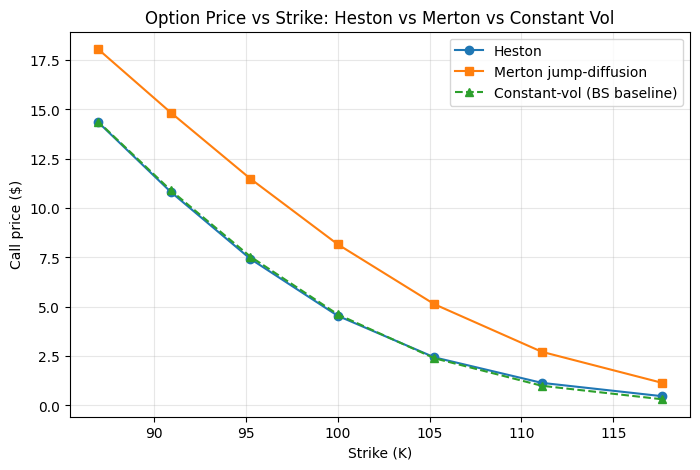

In [ ]:
import matplotlib.pyplot as plt

moneyness = np.array([0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15])
strikes = S0 / moneyness   # so moneyness = S0/K as specified

heston_calls, merton_calls = [], []

for K_i in strikes:
    h = heston_bs_monte_carlo(S0, K_i, r, T, sigma, n_paths=N_PATHS, n_steps=N_STEPS)
    heston_calls.append(h['call_price'])

    c, _ = merton_mc_price(S0, K_i, r, sigma, T, mu_j, delta_j, lam=0.75)  # pick your baseline lambda
    merton_calls.append(c)

# constant-vol (Step 1 / Black-Scholes) baseline across the same strikes — need a BS closed-form or your Step-1 function here
from scipy.stats import norm
def bs_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

bs_calls = [bs_call(S0, K_i, r, sigma, T) for K_i in strikes]

plt.figure(figsize=(8,5))
plt.plot(strikes, heston_calls, marker='o', label='Heston')
plt.plot(strikes, merton_calls, marker='s', label='Merton jump-diffusion')
plt.plot(strikes, bs_calls, marker='^', linestyle='--', label='Constant-vol (BS baseline)')
plt.xlabel('Strike (K)')
plt.ylabel('Call price ($)')
plt.title('Option Price vs Strike: Heston vs Merton vs Constant Vol')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Question 17

In [ ]:
N_PATHS = 1_000_00
N_STEPS = 250

def heston_bs_monte_carlo_american(S0:int, K:int, r:int, T:int, sigma:int, n_paths:int = 500, n_steps:int = 250, rho:float = 0.3):
  S = np.full(n_paths, S0, dtype=float)
  v = np.full(n_paths, v0, dtype=float)
  dt = T / n_steps
  rng = np.random.default_rng(42)
  S_paths = np.zeros((n_steps + 1, n_paths))
  v_paths = np.zeros((n_steps + 1, n_paths))
  S_paths[0] = S
  v_paths[0] = v
  for t in range(n_steps):
    dW1 = np.sqrt(dt) * rng.normal(0, 1, size=n_paths)
    dW2 = np.sqrt(dt) * rng.normal(0, 1, size=n_paths)
    dW_v = dW1
    dW_S = rho * dW1 + np.sqrt(1 - rho**2) * dW2
    v_positive = np.maximum(v, 0.0)
    # Update stock price
    log_returns=(r - 0.5 * v_positive) * dt + np.sqrt(v_positive) * dW_S
    S = S * np.exp(log_returns)

    # Update variance
    v = (
        v_positive
        + kappa * (theta - v_positive) * dt
        + xi * np.sqrt(v_positive) * dW_v
    )

    # Prevent numerical negative variance
    v = np.maximum(v, 0.0)
    S_paths[t + 1] = S
    v_paths[t + 1] = v

  call_payoffs = np.maximum(S - K, 0.0)
  put_payoffs = np.maximum(K - S, 0.0)

  call_price = np.exp(-r * T) * np.mean(call_payoffs)
  put_price = np.exp(-r * T) * np.mean(put_payoffs)

  return dict(
      underlying_paths=S_paths,
      variance_paths=v_paths,
      call_price=call_price,
      put_price=put_price
  )

In [ ]:
q17_result = heston_bs_monte_carlo_american(S0,K,r,T,sigma,N_PATHS,N_STEPS,-0.3)

In [ ]:
print("American call:", q17_result["call_price"])
print("European call:", heston_call_price_rho_minus_03)
print(
    "Early-exercise premium:",
    q17_result["call_price"] - heston_call_price_rho_minus_03)

American call: 1.038555028306576
European call: 1.038555028306576
Early-exercise premium: 0.0


We can reuse the European Heston simulation because the optimal exercise date for a non-dividend-paying American call is ***T***.

Upon comparison, we can find the early-exercise premium is 0.

# Question 18

In [ ]:
def up_and_in_call_from_paths(S_paths,K,barrier,r,T) -> dict:
    barrier_hit = np.any(
        S_paths >= barrier,
        axis=0
    )
    terminal_prices = S_paths[-1]
    plain_call_payoffs = np.maximum(
        terminal_prices - K,
        0.0
    )
    up_and_in_payoffs = np.where(
        barrier_hit,
        plain_call_payoffs,
        0.0
    )
    discount = np.exp(-r * T)
    plain_call_price = (
        discount * np.mean(plain_call_payoffs)
    )
    up_and_in_call_price = (
        discount * np.mean(up_and_in_payoffs)
    )
    return {
        "up_and_in_call_price": up_and_in_call_price,
        "plain_call_price": plain_call_price,
        "barrier_hit_rate": np.mean(barrier_hit),
        "barrier_hit": barrier_hit
    }

In [ ]:
heston_q18 = heston_bs_monte_carlo(S0,110,r,T,sigma,n_paths=100_000,n_steps=250,rho=-0.70)
q18_result = up_and_in_call_from_paths(S_paths=heston_q18["underlying_paths"],K=110,barrier=110,r=r,T=T)


In [ ]:
print(
    q18_result["up_and_in_call_price"],
    q18_result["plain_call_price"]
)

np.isclose(
    q18_result["up_and_in_call_price"],
    q18_result["plain_call_price"]
)

0.8030695142799357 0.8030695142799357


np.True_

In [ ]:
q18_table = pd.DataFrame({
    "Option": [
        "Plain European Call",
        "Up-and-In European Call"
    ],
    "Strike": [110, 110],
    "Barrier": [None, 110],
    "Price": [
        q18_result["plain_call_price"],
        q18_result["up_and_in_call_price"]
    ]
})

q18_table["Price"] = q18_table["Price"].round(2)
q18_table

,Option,Strike,Barrier,Price
0,Plain European Call,110,NaN,0.8
1,Up-and-In European Call,110,110.0,0.8


Under the Heston model with ρ =-0.70, the plain European call and up-and-in call were both valued at \$0.80. This equality is structural rather than coincidental. Because the barrier and strike are both \$110, every path producing a positive terminal call payoff must finish above \$110 and consequently must have reached the barrier. Paths that reach the barrier but subsequently finish below the strike produce zero payoff. Therefore, the barrier condition removes no positive-payoff paths.

# Q19 : Barrier option: European down-and-in put (PDI) Merton jump-diffusion, same setup as Q13 with lambda = 0.75

In [ ]:

S0 = 100.0
r = 0.05
T = 0.25
sigma = 0.20

# ---- Merton jump parameters (Q13 setup) ----
mu_j = -0.5
delta_j = 0.22
lam = 0.75

# ---- Barrier option parameters ----
K = 90.0
B = 90.0

n_paths = 500_000
n_steps = 250
seed = 7


def simulate_paths(S0, r, sigma, T, mu_j, delta_j, lam, n_paths, n_steps, seed):
    """Simulate full Merton jump-diffusion paths (not just terminal value),
    so we can track whether each path ever dips to/through the barrier."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    k = np.exp(mu_j + 0.5 * delta_j**2) - 1          # jump compensator
    drift = (r - 0.5 * sigma**2 - lam * k) * dt

    half = n_paths // 2
    Z = rng.standard_normal((half, n_steps))
    Z = np.vstack([Z, -Z])                            # antithetic variates
    Npaths = 2 * half

    Njumps = rng.poisson(lam * dt, size=(Npaths, n_steps))

    logS = np.full(Npaths, np.log(S0))
    running_min = np.full(Npaths, S0)                  # track min(S) along the path
    for t in range(n_steps):
        diffusion = drift + sigma * np.sqrt(dt) * Z[:, t]
        nj = Njumps[:, t]
        jump_sum = np.where(nj > 0,
                             rng.normal(nj * mu_j, np.sqrt(np.maximum(nj, 1)) * delta_j),
                             0.0)
        logS = logS + diffusion + jump_sum
        St = np.exp(logS)
        running_min = np.minimum(running_min, St)

    ST = np.exp(logS)
    return ST, running_min


ST, running_min = simulate_paths(S0, r, sigma, T, mu_j, delta_j, lam, n_paths, n_steps, seed)
disc = np.exp(-r * T)

# --- Plain (vanilla) European put, same strike K = 90, no barrier ---
vanilla_put_payoff = np.maximum(K - ST, 0.0)
vanilla_put = disc * np.mean(vanilla_put_payoff)
vanilla_put_se = disc * np.std(vanilla_put_payoff) / np.sqrt(n_paths)

# --- Down-and-in put (PDI): alive only if barrier B was touched before maturity ---
knocked_in = running_min <= B
pdi_payoff = np.where(knocked_in, np.maximum(K - ST, 0.0), 0.0)
pdi_price = disc * np.mean(pdi_payoff)
pdi_se = disc * np.std(pdi_payoff) / np.sqrt(n_paths)

# --- Down-and-out put (bonus check): alive only if barrier was NEVER touched ---
pdo_payoff = np.where(~knocked_in, np.maximum(K - ST, 0.0), 0.0)
pdo_price = disc * np.mean(pdo_payoff)

print(f"Vanilla European put (K=90, Merton, lambda=0.75):  {vanilla_put:.2f}  (s.e. {vanilla_put_se:.4f})")
print(f"Down-and-in put  (K=90, B=90):                     {pdi_price:.2f}  (s.e. {pdi_se:.4f})")
print(f"Down-and-out put (K=90, B=90, bonus check):        {pdo_price:.2f}")
print(f"In + Out (should equal vanilla put):                {pdi_price + pdo_price:.2f}")
print(f"Fraction of paths that touched the barrier:         {knocked_in.mean():.4f}")

Vanilla European put (K=90, Merton, lambda=0.75):  4.46  (s.e. 0.0164)
Down-and-in put  (K=90, B=90):                     4.46  (s.e. 0.0164)
Down-and-out put (K=90, B=90, bonus check):        0.00
In + Out (should equal vanilla put):                4.46
Fraction of paths that touched the barrier:         0.2450


The results show that the down-and-in put is worth the same as the vanilla European put, at $4.46. This makes sense because the barrier and the strike are both set at $90. Any path that gives a positive payoff on the put must fall below $90, meaning it must cross the barrier first. Therefore, the barrier does not remove any path that would generate a payoff.

The down-and-out put is valued at $0.00, and the parity check is satisfied: $4.46 + $0.00 = $4.46. This also supports the correctness of the Monte Carlo simulation. Although 24.5% of the simulated paths touched the barrier, these barrier hits do not reduce the value of the down-and-in put. The relatively high probability of hitting the barrier is mainly due to the negative jumps in the Merton model.

Overall, in this particular case, the barrier has no additional effect on the option price**. The down-and-in put behaves like a standard European put, while the down-and-out put has no value.


#Question 21

In [ ]:
import math

# Project base case
S0 = 100.0
K = 100.0
r = 0.05
T = 0.25
sigma = 0.20
N_Q21 = 25

def crr_put(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
    n_steps: int = 25,
    american: bool = True,
) -> dict:
    """Price a European or American put and calculate every node Delta.

    Array entry [j, i] denotes time step j and i up moves.
    """

    if n_steps < 1:
        raise ValueError("n_steps must be positive.")

    dt = T / n_steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    growth = math.exp(r * dt)
    discount = 1.0 / growth
    p = (growth - d) / (u - d)

    if not 0.0 < p < 1.0:
        raise ValueError("The risk-neutral probability is outside (0, 1).")

    shape = (n_steps + 1, n_steps + 1)
    stock = np.full(shape, np.nan)
    value = np.full(shape, np.nan)
    continuation = np.full(shape, np.nan)
    delta = np.full(shape, np.nan)
    exercise_now = np.zeros(shape, dtype=bool)

    for j in range(n_steps + 1):
        i = np.arange(j + 1)
        stock[j, : j + 1] = S0 * u**i * d ** (j - i)

    value[n_steps, : n_steps + 1] = np.maximum(
        K - stock[n_steps, : n_steps + 1],
        0.0,
    )

    for j in range(n_steps - 1, -1, -1):
        for i in range(j + 1):
            hold = discount * (
                p * value[j + 1, i + 1]
                + (1.0 - p) * value[j + 1, i]
            )
            intrinsic = max(K - stock[j, i], 0.0)

            continuation[j, i] = hold
            exercise_now[j, i] = (
                american and intrinsic > hold + 1.0e-12
            )
            value[j, i] = (
                intrinsic if exercise_now[j, i] else hold
            )

            child_slope = (
                value[j + 1, i + 1] - value[j + 1, i]
            ) / (
                stock[j + 1, i + 1] - stock[j + 1, i]
            )

            # If exercise is optimal, the active payoff K-S has Delta -1.
            delta[j, i] = (
                -1.0 if exercise_now[j, i] else child_slope
            )

    return {
        "price": float(value[0, 0]),
        "delta_0": float(delta[0, 0]),
        "stock": stock,
        "value": value,
        "continuation": continuation,
        "delta": delta,
        "exercise_now": exercise_now,
        "dt": dt,
        "u": u,
        "d": d,
        "p": p,
        "S0": S0,
        "K": K,
        "r": r,
        "n_steps": n_steps,
        "american": american,
    }


def american_put_node_table(tree: dict) -> pd.DataFrame:
    """Return the price, Delta, and exercise decision at every node."""

    rows = []
    for j in range(tree["n_steps"]):
        for i in range(j + 1):
            rows.append(
                {
                    "Step": j,
                    "Up moves": i,
                    "Stock": tree["stock"][j, i],
                    "Put value": tree["value"][j, i],
                    "Continuation": tree["continuation"][j, i],
                    "Delta": tree["delta"][j, i],
                    "Exercise now": tree["exercise_now"][j, i],
                }
            )
    return pd.DataFrame(rows)


def short_put_cash_account(tree: dict, moves: str) -> pd.DataFrame:
    """Trace a seller's self-financing Delta hedge along one CRR path.

    A negative share trade means a sale/short sale; a positive trade means
    a purchase. The hedge stops and settles if early exercise occurs.
    """

    n_steps = tree["n_steps"]
    moves = moves.upper().replace(" ", "")

    if len(moves) != n_steps or any(move not in "UD" for move in moves):
        raise ValueError(f"Enter exactly {n_steps} moves, each U or D.")

    stock = tree["stock"]
    value = tree["value"]
    delta = tree["delta"]
    exercise_now = tree["exercise_now"]
    K = tree["K"]
    cash_growth = math.exp(tree["r"] * tree["dt"])

    premium = value[0, 0]
    shares = delta[0, 0]
    cash_after = premium - shares * stock[0, 0]

    rows = [
        {
            "Step": 0,
            "Move": "Start",
            "Stock": stock[0, 0],
            "Put value": value[0, 0],
            "Event": "Initial hedge",
            "Shares traded": shares,
            "Shares after trade": shares,
            "Cash before trade": premium,
            "Cash after trade": cash_after,
            "Settlement": 0.0,
            "Residual": np.nan,
            "Hedge error": 0.0,
        }
    ]

    up_moves = 0

    for j, move in enumerate(moves, start=1):
        if move == "U":
            up_moves += 1

        spot = stock[j, up_moves]
        cash_before = cash_after * cash_growth
        early = j < n_steps and exercise_now[j, up_moves]
        maturity = j == n_steps

        if early or maturity:
            settlement = max(K - spot, 0.0)
            shares_after = 0.0
            shares_traded = -shares
            cash_after = cash_before - shares_traded * spot
            residual = cash_after - settlement
            event = "Early exercise" if early else "Maturity"
        else:
            settlement = 0.0
            residual = np.nan
            event = "Rebalance"
            shares_after = delta[j, up_moves]
            shares_traded = shares_after - shares
            cash_after = cash_before - shares_traded * spot

        hedge_error = (
            shares_after * spot + cash_after - value[j, up_moves]
        )

        rows.append(
            {
                "Step": j,
                "Move": move,
                "Stock": spot,
                "Put value": value[j, up_moves],
                "Event": event,
                "Shares traded": shares_traded,
                "Shares after trade": shares_after,
                "Cash before trade": cash_before,
                "Cash after trade": cash_after,
                "Settlement": settlement,
                "Residual": residual,
                "Hedge error": hedge_error,
            }
        )

        shares = shares_after

        if early or maturity:
            break

    return pd.DataFrame(rows)

In [ ]:
q21_american = crr_put(
    S0, K, r, sigma, T,
    n_steps=N_Q21,
    american=True
)

q21_european = crr_put(
    S0, K, r, sigma, T,
    n_steps=N_Q21,
    american=False
)

q21_summary = pd.DataFrame({
    "Option": ["European put", "American put"],
    "Price": [q21_european["price"], q21_american["price"]],
    "Initial Delta": [
        q21_european["delta_0"],
        q21_american["delta_0"]
    ],
    "Early-exercise premium": [
        0.0,
        q21_american["price"] - q21_european["price"]
    ]
})

q21_summary_display = q21_summary.copy()
q21_summary_display["Price"] = q21_summary_display["Price"].map("${:.2f}".format)
q21_summary_display["Initial Delta"] = (
    q21_summary_display["Initial Delta"].map("{:.4f}".format)
)
q21_summary_display["Early-exercise premium"] = (
    q21_summary_display["Early-exercise premium"].map("${:.2f}".format)
)
display(q21_summary_display)

# Full long-form node table: 325 nonterminal nodes.
q21_node_table = american_put_node_table(q21_american)

# Compact display containing every node Delta, grouped by time step.
q21_delta_by_step = pd.DataFrame({
    "Step": range(N_Q21),
    "Deltas from 0 through j up moves": [
        np.round(
            q21_american["delta"][j, :j + 1],
            4
        ).tolist()
        for j in range(N_Q21)
    ]
})

print(f"Calculated {len(q21_node_table)} nonterminal node Deltas.")
display(q21_delta_by_step)


,Option,Price,Initial Delta,Early-exercise premium
0,European put,$3.41,-0.4318,$0.00
1,American put,$3.52,-0.4502,$0.11


Calculated 325 nonterminal node Deltas.


,Step,Deltas from 0 through j up moves
0,0,[-0.4502]
1,1,"[-0.5384, -0.368]"
2,2,"[-0.6309, -0.4521, -0.2896]"
3,3,"[-0.7242, -0.5439, -0.3666, -0.2179]"
4,4,"[-0.8143, -0.6402, -0.4541, -0.285, -0.1553]"
5,5,"[-0.8973, -0.737, -0.5499, -0.3647, -0.2106, -..."
6,6,"[-0.9697, -0.8298, -0.6505, -0.4561, -0.2795, ..."
7,7,"[-1.0, -0.9141, -0.7512, -0.5566, -0.3624, -0...."
8,8,"[-1.0, -1.0, -0.8468, -0.662, -0.4584, -0.273,..."
9,9,"[-1.0, -1.0, -0.9326, -0.7667, -0.5644, -0.359..."


In [ ]:
# This alternating path avoids early exercise and displays all 25 hedge steps.
q21_path = "UD" * 12 + "D"
q21_cash_account = short_put_cash_account(q21_american, q21_path)

q21_cash_columns = [
    "Step", "Move", "Stock", "Put value", "Event",
    "Shares traded", "Shares after trade",
    "Cash after trade", "Settlement", "Residual"
]

q21_cash_display = q21_cash_account[q21_cash_columns].copy()
q21_cash_display["Stock"] = q21_cash_display["Stock"].map("${:.2f}".format)
q21_cash_display["Put value"] = q21_cash_display["Put value"].map("${:.2f}".format)
q21_cash_display["Shares traded"] = q21_cash_display["Shares traded"].map("{:.4f}".format)
q21_cash_display["Shares after trade"] = q21_cash_display["Shares after trade"].map("{:.4f}".format)
q21_cash_display["Cash after trade"] = q21_cash_display["Cash after trade"].map("${:.2f}".format)
q21_cash_display["Settlement"] = q21_cash_display["Settlement"].map("${:.2f}".format)
q21_cash_display["Residual"] = q21_cash_display["Residual"].map(
    lambda x: "" if pd.isna(x) else f"{x:.2e}"
)
display(q21_cash_display)

# Validation: an all-down path reaches the exercise boundary and stops early.
q21_early_exercise_check = short_put_cash_account(
    q21_american,
    "D" * N_Q21
)
last_early_row = q21_early_exercise_check.iloc[-1]
print(
    "Early-exercise validation:",
    f"step={int(last_early_row['Step'])},",
    f"event={last_early_row['Event']},",
    f"residual={last_early_row['Residual']:.2e}"
)


,Step,Move,Stock,Put value,Event,Shares traded,Shares after trade,Cash after trade,Settlement,Residual
0,0,Start,$100.00,$3.52,Initial hedge,-0.4502,-0.4502,$48.54,$0.00,
1,1,U,$102.02,$2.63,Rebalance,0.0822,-0.3680,$40.18,$0.00,
2,2,D,$100.00,$3.40,Rebalance,-0.0841,-0.4521,$48.61,$0.00,
3,3,U,$102.02,$2.51,Rebalance,0.0856,-0.3666,$39.90,$0.00,
4,4,D,$100.00,$3.27,Rebalance,-0.0875,-0.4541,$48.68,$0.00,
5,5,U,$102.02,$2.38,Rebalance,0.0894,-0.3647,$39.58,$0.00,
6,6,D,$100.00,$3.13,Rebalance,-0.0914,-0.4561,$48.75,$0.00,
7,7,U,$102.02,$2.23,Rebalance,0.0937,-0.3624,$39.21,$0.00,
8,8,D,$100.00,$2.99,Rebalance,-0.0960,-0.4584,$48.83,$0.00,
9,9,U,$102.02,$2.09,Rebalance,0.0988,-0.3595,$38.77,$0.00,


Early-exercise validation: step=7, event=Early exercise, residual=0.00e+00


In [ ]:
q21_cash_display.to_csv('Q_21_cash_account.csv')


### Answer to Question 21

The 25-step CRR American put price is **\$3.52**, with an initial Delta of **−0.4502**. The comparable 25-step European put is **\$3.41**, so the American early-exercise premium is approximately **\$0.11**. The code calculates all 325 nonterminal-node Deltas and identifies the exercise region by comparing intrinsic value with continuation value.

For the chosen 25-move path, the seller receives the option premium, holds the put Delta in shares, lets the cash account accrue at the risk-free rate, and rebalances at every step. The final hedge residual is numerically zero. The separate all-down validation reaches the early-exercise boundary at step 7 and also settles with zero residual.


#Question 22

In [ ]:
def _grid_interp(
    grid: np.ndarray,
    values: np.ndarray,
    x,
) -> np.ndarray:
    """Linear interpolation that also handles one-point state grids."""

    x = np.asarray(x, dtype=float)
    if len(grid) == 1:
        return np.full_like(x, values[0], dtype=float)
    return np.interp(x, grid, values)


def asian_arithmetic_put_crr(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
    n_steps: int = 25,
    n_average_grid: int = 401,
) -> dict:
    """Price a European arithmetic-average put on an augmented CRR tree.

    The averaging dates are t_0,...,t_N, so S_0 is included. Running
    averages do not recombine; every stock node therefore carries a grid of
    possible running-average states.
    """

    if n_steps < 1:
        raise ValueError("n_steps must be positive.")
    if n_average_grid < 2:
        raise ValueError("n_average_grid must be at least 2.")

    dt = T / n_steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    growth = math.exp(r * dt)
    discount = 1.0 / growth
    p = (growth - d) / (u - d)

    if not 0.0 < p < 1.0:
        raise ValueError("The risk-neutral probability is outside (0, 1).")

    stock = np.full((n_steps + 1, n_steps + 1), np.nan)
    for j in range(n_steps + 1):
        for i in range(j + 1):
            stock[j, i] = S0 * u**i * d ** (j - i)

    # Bounds for cumulative sum Q_j = S_0 + ... + S_j.
    sum_min = np.full_like(stock, np.inf)
    sum_max = np.full_like(stock, -np.inf)
    sum_min[0, 0] = S0
    sum_max[0, 0] = S0

    for j in range(n_steps):
        for i in range(j + 1):
            for child_i in (i, i + 1):
                child_stock = stock[j + 1, child_i]
                sum_min[j + 1, child_i] = min(
                    sum_min[j + 1, child_i],
                    sum_min[j, i] + child_stock,
                )
                sum_max[j + 1, child_i] = max(
                    sum_max[j + 1, child_i],
                    sum_max[j, i] + child_stock,
                )

    average_grids: dict[tuple[int, int], np.ndarray] = {}
    for j in range(n_steps + 1):
        for i in range(j + 1):
            lower = sum_min[j, i] / (j + 1)
            upper = sum_max[j, i] / (j + 1)

            if math.isclose(lower, upper, rel_tol=0.0, abs_tol=1.0e-13):
                average_grids[j, i] = np.array([0.5 * (lower + upper)])
            else:
                average_grids[j, i] = np.linspace(
                    lower,
                    upper,
                    n_average_grid,
                )

    values: dict[tuple[int, int], np.ndarray] = {}
    deltas: dict[tuple[int, int], np.ndarray] = {}

    for i in range(n_steps + 1):
        average = average_grids[n_steps, i]
        values[n_steps, i] = np.maximum(K - average, 0.0)

    for j in range(n_steps - 1, -1, -1):
        for i in range(j + 1):
            average = average_grids[j, i]
            average_down = (
                (j + 1) * average + stock[j + 1, i]
            ) / (j + 2)
            average_up = (
                (j + 1) * average + stock[j + 1, i + 1]
            ) / (j + 2)

            value_down = _grid_interp(
                average_grids[j + 1, i],
                values[j + 1, i],
                average_down,
            )
            value_up = _grid_interp(
                average_grids[j + 1, i + 1],
                values[j + 1, i + 1],
                average_up,
            )

            values[j, i] = discount * (
                (1.0 - p) * value_down + p * value_up
            )
            deltas[j, i] = (
                value_up - value_down
            ) / (
                stock[j + 1, i + 1] - stock[j + 1, i]
            )

    return {
        "price": float(values[0, 0][0]),
        "delta_0": float(deltas[0, 0][0]),
        "stock": stock,
        "average_grids": average_grids,
        "values": values,
        "deltas": deltas,
        "n_steps": n_steps,
        "K": K,
        "r": r,
        "dt": dt,
        "u": u,
        "d": d,
        "p": p,
        "n_average_grid": n_average_grid,
    }


def asian_put_hedge_ledger(model: dict, path: str) -> pd.DataFrame:
    """Trace the Asian-put seller's hedge and running average along a path."""

    n_steps = model["n_steps"]
    path = path.upper().replace(" ", "")

    if len(path) != n_steps or any(move not in "UD" for move in path):
        raise ValueError(f"Enter exactly {n_steps} moves, each U or D.")

    stock_tree = model["stock"]
    grids = model["average_grids"]
    values = model["values"]
    deltas = model["deltas"]
    K = model["K"]
    cash_growth = math.exp(model["r"] * model["dt"])

    def state_value(j: int, i: int, average: float) -> float:
        return float(
            _grid_interp(grids[j, i], values[j, i], [average])[0]
        )

    def state_delta(j: int, i: int, average: float) -> float:
        return float(
            _grid_interp(grids[j, i], deltas[j, i], [average])[0]
        )

    up_moves = 0
    spot = stock_tree[0, 0]
    cumulative_sum = spot
    average = spot
    option_value = state_value(0, 0, average)
    shares = state_delta(0, 0, average)
    cash_after = option_value - shares * spot

    rows = [
        {
            "Step": 0,
            "Move": "Start",
            "Stock": spot,
            "Running average": average,
            "Option value": option_value,
            "Shares traded": shares,
            "Shares after trade": shares,
            "Interest earned": 0.0,
            "Cash before trade": option_value,
            "Cash after trade": cash_after,
            "Payoff": np.nan,
            "Residual": np.nan,
            "Hedge error": 0.0,
        }
    ]

    for j, move in enumerate(path, start=1):
        if move == "U":
            up_moves += 1

        spot = stock_tree[j, up_moves]
        cumulative_sum += spot
        average = cumulative_sum / (j + 1)

        interest = cash_after * (cash_growth - 1.0)
        cash_before = cash_after + interest

        if j < n_steps:
            option_value = state_value(j, up_moves, average)
            shares_after = state_delta(j, up_moves, average)
            payoff = np.nan
        else:
            option_value = max(K - average, 0.0)
            shares_after = 0.0
            payoff = option_value

        shares_traded = shares_after - shares
        cash_after = cash_before - shares_traded * spot
        portfolio_before_payoff = shares_after * spot + cash_after

        if j == n_steps:
            residual = cash_after - payoff
            hedge_error = residual
        else:
            residual = np.nan
            hedge_error = portfolio_before_payoff - option_value

        rows.append(
            {
                "Step": j,
                "Move": move,
                "Stock": spot,
                "Running average": average,
                "Option value": option_value,
                "Shares traded": shares_traded,
                "Shares after trade": shares_after,
                "Interest earned": interest,
                "Cash before trade": cash_before,
                "Cash after trade": cash_after,
                "Payoff": payoff,
                "Residual": residual,
                "Hedge error": hedge_error,
            }
        )

        shares = shares_after

    return pd.DataFrame(rows)

In [ ]:
grid_sizes = [101, 201, 401]
q22_models = {
    grid_size: asian_arithmetic_put_crr(
        S0, K, r, sigma, T,
        n_steps=25,
        n_average_grid=grid_size
    )
    for grid_size in grid_sizes
}

q22_asian = q22_models[401]

q22_comparison = pd.DataFrame({
    "Option": [
        "American put (Q21)",
        "Arithmetic-average Asian put (Q22)"
    ],
    "Price": [q21_american["price"], q22_asian["price"]],
    "Initial Delta": [
        q21_american["delta_0"],
        q22_asian["delta_0"]
    ]
})

q22_comparison_display = q22_comparison.copy()
q22_comparison_display["Price"] = q22_comparison_display["Price"].map("${:.2f}".format)
q22_comparison_display["Initial Delta"] = (
    q22_comparison_display["Initial Delta"].map("{:.4f}".format)
)
display(q22_comparison_display)

q22_convergence = pd.DataFrame({
    "Average-grid states": grid_sizes,
    "Asian put price": [q22_models[m]["price"] for m in grid_sizes],
    "Initial Delta": [q22_models[m]["delta_0"] for m in grid_sizes]
})

q22_convergence_display = q22_convergence.copy()
q22_convergence_display["Asian put price"] = (
    q22_convergence_display["Asian put price"].map("${:.4f}".format)
)
q22_convergence_display["Initial Delta"] = (
    q22_convergence_display["Initial Delta"].map("{:.6f}".format)
)
display(q22_convergence_display)

q22_delta_state_count = sum(
    delta_values.size
    for delta_values in q22_asian["deltas"].values()
)
print(
    f"Stored {q22_delta_state_count:,} Asian-option Delta states "
    "across the augmented tree."
)


,Option,Price,Initial Delta
0,American put (Q21),$3.52,-0.4502
1,Arithmetic-average Asian put (Q22),$1.98,-0.4287


,Average-grid states,Asian put price,Initial Delta
0,101,$1.9800,-0.428688
1,201,$1.9787,-0.428664
2,401,$1.9783,-0.428659


Stored 110,725 Asian-option Delta states across the augmented tree.


In [ ]:
# Alternating moves keep the stock near ATM while the running average evolves.
q22_path = "DU" * 12 + "D"
q22_cash_account = asian_put_hedge_ledger(q22_asian, q22_path)

q22_cash_columns = [
    "Step", "Move", "Stock", "Running average", "Option value",
    "Shares traded", "Shares after trade", "Cash after trade",
    "Payoff", "Residual"
]

q22_cash_display = q22_cash_account[q22_cash_columns].copy()
q22_cash_display["Stock"] = q22_cash_display["Stock"].map("${:.2f}".format)
q22_cash_display["Running average"] = q22_cash_display["Running average"].map("${:.2f}".format)
q22_cash_display["Option value"] = q22_cash_display["Option value"].map("${:.4f}".format)
q22_cash_display["Shares traded"] = q22_cash_display["Shares traded"].map("{:.4f}".format)
q22_cash_display["Shares after trade"] = q22_cash_display["Shares after trade"].map("{:.4f}".format)
q22_cash_display["Cash after trade"] = q22_cash_display["Cash after trade"].map("${:.4f}".format)
q22_cash_display["Payoff"] = q22_cash_display["Payoff"].map(
    lambda x: "" if pd.isna(x) else f"${x:.4f}"
)
q22_cash_display["Residual"] = q22_cash_display["Residual"].map(
    lambda x: "" if pd.isna(x) else f"{x:.2e}"
)
display(q22_cash_display)


,Step,Move,Stock,Running average,Option value,Shares traded,Shares after trade,Cash after trade,Payoff,Residual
0,0,Start,$100.00,$100.00,$1.9783,-0.4287,-0.4287,$44.8443,,
1,1,D,$98.02,$99.01,$2.8496,-0.1165,-0.5452,$56.2865,,
2,2,U,$100.00,$99.34,$1.7982,0.1433,-0.4018,$41.9814,,
3,3,D,$98.02,$99.01,$2.6149,-0.1109,-0.5128,$52.8773,,
4,4,U,$100.00,$99.21,$1.6260,0.1375,-0.3752,$39.1492,,
5,5,D,$98.02,$99.01,$2.3886,-0.1050,-0.4802,$49.4611,,
6,6,U,$100.00,$99.15,$1.4624,0.1313,-0.3490,$36.3581,,
7,7,D,$98.02,$99.01,$2.1715,-0.0986,-0.4475,$46.0376,,
8,8,U,$100.00,$99.12,$1.3084,0.1244,-0.3231,$33.6228,,
9,9,D,$98.02,$99.01,$1.9651,-0.0915,-0.4146,$42.6036,,


In [ ]:
q22_cash_display.to_csv('Q_22_cash_account.csv')

### Answer to Question 22

Using 401 running-average grid states, the arithmetic-average Asian put price is **\$1.98** and its initial Delta is **−0.4287**. The values are stable to the nearest cent when the grid is increased from 101 to 201 and 401 states.

For this base case, the Asian put is cheaper than the Q21 American put (**\$1.98** versus **\$3.52**). Averaging smooths stock-price fluctuations, while the American put also includes an early-exercise right. The Asian hedge is path-dependent: two paths arriving at the same stock node can require different Deltas because their running averages differ. Along the selected path, the final residual is approximately **\$0.0002**, which is negligible to the nearest cent and results from interpolation on the running-average grid.
